- ### Omar Khaled			221002374
- ### Ahmed Hamimi		221011417


---

# Walmart Real Data OLAP, Fuzzy Logic, Machine Learning, and Gradio DSS



This notebook builds a complete Decision Support System using the Walmart Recruiting Store Sales Forecasting dataset.

The notebook covers:

- Real Walmart dataset source and business description
- Data loading from local CSV files or Kaggle zip files
- Data cleaning and preparation
- Data warehouse merged view
- Time and DSS feature engineering
- OLAP operations
- Cube
- Roll-up
- Drill-down
- Slice
- Dice
- Pivot
- visualizations with DSS interpretation
- Fuzzy Logic Sales Risk DSS
- Random Forest machine learning model
- Gradio deployment interface
- Final business recommendations

Dataset source:

https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data

---

# 1. Business Problem

Walmart managers need to understand sales performance across stores, departments, time periods, holidays, and promotional markdowns.

The business questions are:

| Question | DSS value |
|---|---|
| Which stores generate the highest sales? | Allocate resources to strong stores |
| Which departments are weak? | Review pricing, stock, and promotions |
| Do holidays increase sales? | Plan holiday campaigns |
| Do markdowns improve sales? | Evaluate promotion effectiveness |
| Which store and department combinations are risky? | Prioritize management attention |
| Can a small model predict risk level? | Support simple deployment decisions |

The final system gives a practical recommendation for retail decision makers.

---

# 2. Dataset Source and Why It Is Real

The dataset comes from Kaggle:

https://www.kaggle.com/c/walmart-recruiting-store-sales-forecasting/data

Kaggle describes the dataset as historical sales data for 45 Walmart stores located in different regions.

This dataset is suitable because:

- It is publicly available.
- It is not created inside this notebook.
- It contains real retail structure.
- It contains store, department, date, sales, holiday, markdown, and economic features.
- It supports OLAP analysis and DSS recommendations.

## Main files

| File | Role | Business meaning |
|---|---|---|
| train.csv | Fact table | Weekly sales by store, department, and date |
| stores.csv | Dimension table | Store type and store size |
| features.csv | External feature table | Temperature, fuel price, markdowns, CPI, unemployment, and holiday flag |
| test.csv | Future prediction table | Future store, department, and date combinations |
| sampleSubmission.csv | Kaggle format | Submission structure for forecasting |

# 3. Main Columns and Business Meaning

## train.csv

| Column | Meaning | Business use |
|---|---|---|
| Store | Store number | Compare branches |
| Dept | Department number | Compare product departments |
| Date | Week date | Time analysis |
| Weekly_Sales | Sales amount for that week | Main OLAP measure |
| IsHoliday | Holiday week flag | Compare holiday and non-holiday behavior |

## stores.csv

| Column | Meaning | Business use |
|---|---|---|
| Store | Store number | Join key |
| Type | Store type A, B, or C | Compare sales by store format |
| Size | Store size | Study relationship between size and sales |

## features.csv

| Column | Meaning | Business use |
|---|---|---|
| Store | Store number | Join key |
| Date | Week date | Join key and time analysis |
| Temperature | Weather temperature | Check weather effect |
| Fuel_Price | Fuel price | Economic pressure indicator |
| MarkDown1 to MarkDown5 | Promotional markdown values | Measure promotions |
| CPI | Consumer Price Index | Inflation and price level indicator, It helps the DSS understand how general price changes may affect customer spending and weekly sales. |
| Unemployment | Unemployment rate | Local economic pressure indicator, It helps the DSS understand whether local economic conditions may reduce customer spending and increase sales risk |
| IsHoliday | Holiday week flag | Join key and seasonal analysis |

---

# 4. Install and Import Required Libraries

This cell imports the libraries used in the notebook.

The notebook uses:

- pandas for data analysis
- numpy for numerical work
- matplotlib for charts
- scikit-learn for the Random Forest model
- gradio for the deployment interface



In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path
import zipfile
import warnings

warnings.filterwarnings("ignore")


def ensure_package(import_name, pip_name=None):
    """Install a package only if it is missing."""
    if importlib.util.find_spec(import_name) is None:
        pip_name = pip_name or import_name
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])


# Core packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

# Machine learning packages
ensure_package("sklearn", "scikit-learn")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Gradio is optional until the deployment section
try:
    import gradio as gr
    GRADIO_AVAILABLE = True
except Exception:
    GRADIO_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
np.random.seed(42)

Installing scikit-learn...


---

# 5. Locate and Load the Dataset

This notebook is designed to work in different folder layouts.

It can read the dataset when:

- The notebook is placed in the same folder as the CSV files.
- The CSV files are inside subfolders named `train.csv`, `features.csv`, or similar.
- The original Kaggle zip file is in the same folder.
- The nested Kaggle zip files are still compressed.

Expected files:

- train.csv
- stores.csv
- features.csv

In [2]:
BASE_DIR = Path.cwd()

# Safety rule
# Do not recursively scan the operating system root folder.
if BASE_DIR == Path(BASE_DIR.anchor) and Path("/mnt/data").exists():
    BASE_DIR = Path("/mnt/data")

print("Current working directory:", BASE_DIR)


def extract_zip(zip_path, extract_to):
    """Extract a zip file safely."""
    zip_path = Path(zip_path)
    extract_to = Path(extract_to)
    extract_to.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_to)
    return extract_to


def extract_available_zips(search_dir):
    """Extract Kaggle zip files and nested csv zip files if they exist."""
    search_dir = Path(search_dir)

    if search_dir == Path(search_dir.anchor):
        print("Skipping root folder scan:", search_dir)
        return

    main_zip_names = [
        "walmart-recruiting-store-sales-forecasting.zip",
        "walmart-recruiting-store-sales-forecasting.zip.zip"
    ]

    for zip_name in main_zip_names:
        for zip_path in search_dir.rglob(zip_name):
            target_dir = zip_path.parent / "walmart_extracted"
            if not target_dir.exists():
                print("Extracting main Kaggle zip:", zip_path)
                extract_zip(zip_path, target_dir)

    for nested_zip in search_dir.rglob("*.csv.zip"):
        target_dir = nested_zip.parent
        csv_name = nested_zip.name.replace(".zip", "")
        if not (target_dir / csv_name).exists():
            print("Extracting nested csv zip:", nested_zip)
            extract_zip(nested_zip, target_dir)


def find_file(filename, search_dir):
    """Find a file recursively by exact filename."""
    search_dir = Path(search_dir)

    if search_dir == Path(search_dir.anchor):
        return None

    matches = [p for p in search_dir.rglob(filename) if p.is_file()]
    if matches:
        return matches[0]
    return None


search_roots = [BASE_DIR]

if Path("/mnt/data").exists() and Path("/mnt/data") not in search_roots:
    search_roots.append(Path("/mnt/data"))

for root in search_roots:
    extract_available_zips(root)

required_files = ["train.csv", "stores.csv", "features.csv"]
file_paths = {}

for name in required_files:
    found_path = None
    for root in search_roots:
        found_path = find_file(name, root)
        if found_path is not None:
            break
    file_paths[name] = found_path

file_paths

Current working directory: c:\Users\dell\Desktop\assi 3


{'train.csv': WindowsPath('c:/Users/dell/Desktop/assi 3/train.csv/train.csv'),
 'stores.csv': WindowsPath('c:/Users/dell/Desktop/assi 3/stores.csv'),
 'features.csv': WindowsPath('c:/Users/dell/Desktop/assi 3/features.csv/features.csv')}

## Check dataset availability

This cell stops early if any required file is missing.

If an error appears:

- Put the notebook inside the `assi 3` folder.
- Make sure the Kaggle files exist in the same folder or inside subfolders.
- Keep the original Kaggle zip in the folder if you did not extract it manually.

In [3]:
missing = [name for name, path in file_paths.items() if path is None]

if missing:
    raise FileNotFoundError(
        "Missing files: " + ", ".join(missing) +
        "\nPlace train.csv, stores.csv, and features.csv in this folder or keep the Kaggle zip here."
    )

for name, path in file_paths.items():
    print(f"{name}: {path}")

train.csv: c:\Users\dell\Desktop\assi 3\train.csv\train.csv
stores.csv: c:\Users\dell\Desktop\assi 3\stores.csv
features.csv: c:\Users\dell\Desktop\assi 3\features.csv\features.csv


# 6. Load CSV Files

We load the three main files.

The `train.csv` file is the sales fact table.

The `stores.csv` file is the store dimension table.

The `features.csv` file adds external factors and promotional markdowns.

In [4]:
train = pd.read_csv(file_paths["train.csv"])
stores = pd.read_csv(file_paths["stores.csv"])
features = pd.read_csv(file_paths["features.csv"])

print("train shape:", train.shape)
print("stores shape:", stores.shape)
print("features shape:", features.shape)

print("\nTrain sample")
display(train.head())

print("\nStores sample")
display(stores.head())

print("\nFeatures sample")
display(features.head())

train shape: (421570, 5)
stores shape: (45, 3)
features shape: (8190, 12)

Train sample


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,"24,924.500",False
1,1,1,2010-02-12,"46,039.490",True
2,1,1,2010-02-19,"41,595.550",False
3,1,1,2010-02-26,"19,403.540",False
4,1,1,2010-03-05,"21,827.900",False



Stores sample


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



Features sample


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.310,2.572,NaN,NaN,NaN,NaN,NaN,211.096,8.106,False
1,1,2010-02-12,38.510,2.548,NaN,NaN,NaN,NaN,NaN,211.242,8.106,True
2,1,2010-02-19,39.930,2.514,NaN,NaN,NaN,NaN,NaN,211.289,8.106,False
3,1,2010-02-26,46.630,2.561,NaN,NaN,NaN,NaN,NaN,211.320,8.106,False
4,1,2010-03-05,46.500,2.625,NaN,NaN,NaN,NaN,NaN,211.350,8.106,False


---

# 7. Dataset Structure Check

This step checks:

- Column names
- Data types
- Missing values
- Basic descriptive statistics

This helps us understand the data before cleaning.

In [5]:
print("Train columns")
print(train.columns.tolist())

print("\nStores columns")
print(stores.columns.tolist())

print("\nFeatures columns")
print(features.columns.tolist())

print("\nTrain info")
train.info()

print("\nStores info")
stores.info()

print("\nFeatures info")
features.info()

Train columns
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Stores columns
['Store', 'Type', 'Size']

Features columns
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Train info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Stores info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64

## Missing values before cleaning

Markdown columns usually contain missing values because not every week has a markdown promotion.

For this DSS, missing markdown values mean no recorded promotion value.

So we will replace missing markdowns with zero.

In [6]:
def missing_table(df, name):
    missing = df.isna().sum().reset_index()
    missing.columns = ["Column", "Missing_Count"]
    missing["Missing_Percent"] = missing["Missing_Count"] / len(df) * 100
    missing = missing.sort_values("Missing_Count", ascending=False)
    print(f"Missing values in {name}")
    display(missing)
    return missing

missing_train = missing_table(train, "train")
missing_stores = missing_table(stores, "stores")
missing_features = missing_table(features, "features")

Missing values in train


,Column,Missing_Count,Missing_Percent
0,Store,0,0.000
1,Dept,0,0.000
2,Date,0,0.000
3,Weekly_Sales,0,0.000
4,IsHoliday,0,0.000


Missing values in stores


,Column,Missing_Count,Missing_Percent
0,Store,0,0.000
1,Type,0,0.000
2,Size,0,0.000


Missing values in features


,Column,Missing_Count,Missing_Percent
5,MarkDown2,5269,64.335
7,MarkDown4,4726,57.705
6,MarkDown3,4577,55.885
4,MarkDown1,4158,50.769
8,MarkDown5,4140,50.549
9,CPI,585,7.143
10,Unemployment,585,7.143
0,Store,0,0.000
1,Date,0,0.000
2,Temperature,0,0.000


## Visualization 1: Missing values in features.csv

This chart shows which external features need cleaning.

DSS interpretation:

- MarkDown columns usually have the largest missing values.
- This supports the business assumption that markdown events do not happen every week.
- Replacing missing markdowns with zero is a practical decision for promotion analysis.

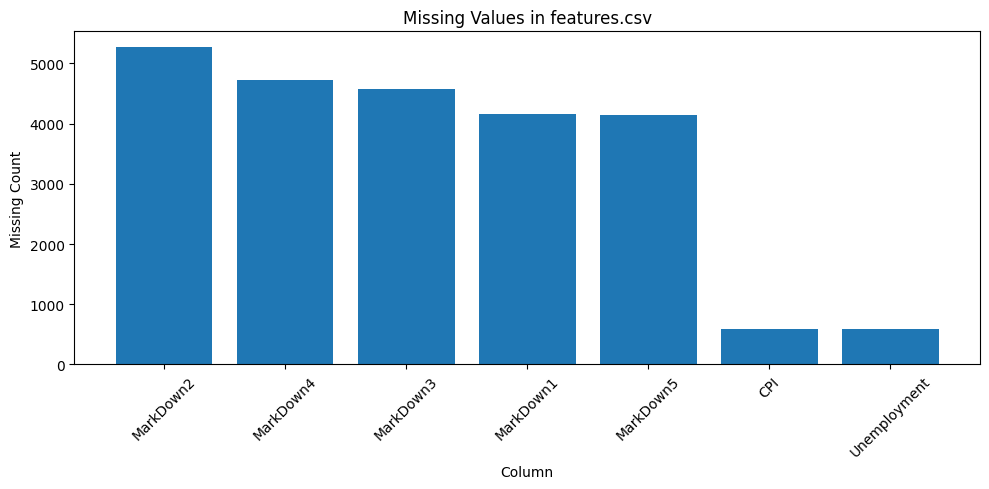

In [7]:
features_missing_plot = missing_features[missing_features["Missing_Count"] > 0]

if len(features_missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    plt.bar(features_missing_plot["Column"], features_missing_plot["Missing_Count"])
    plt.title("Missing Values in features.csv")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in features.csv")

---

# 8. Data Cleaning

Cleaning steps:

- Convert Date columns to datetime.
- Fill missing markdown values with zero.
- Fill missing economic and weather values with the median.
- Validate duplicate rows.
- Keep the original raw tables and create a clean analytical table.

In [60]:
train_clean = train.copy()
stores_clean = stores.copy()
features_clean = features.copy()

# Convert date columns
train_clean["Date"] = pd.to_datetime(train_clean["Date"])
features_clean["Date"] = pd.to_datetime(features_clean["Date"])
print("train_clean Date type:")
print(train_clean["Date"].dtype)
print("\nfeatures_clean Date type:")
print(features_clean["Date"].dtype)
print("======================================")

# Fill markdown missing values with zero
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
for col in markdown_cols:
    features_clean[col] = features_clean[col].fillna(0)

# Fill other numeric missing values using median
numeric_feature_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
for col in numeric_feature_cols:
    features_clean[col] = features_clean[col].fillna(features_clean[col].median())

print("Train duplicates:", train_clean.duplicated().sum())
print("Stores duplicates:", stores_clean.duplicated().sum())
print("Features duplicates:", features_clean.duplicated().sum())

print("\nMissing values after cleaning in features")
display(features_clean.isna().sum().reset_index().rename(columns={"index": "Column", 0: "Missing_Count"}))

train_clean Date type:
datetime64[ns]

features_clean Date type:
datetime64[ns]
Train duplicates: 0
Stores duplicates: 0
Features duplicates: 0

Missing values after cleaning in features


,Column,Missing_Count
0,Store,0
1,Date,0
2,Temperature,0
3,Fuel_Price,0
4,MarkDown1,0
5,MarkDown2,0
6,MarkDown3,0
7,MarkDown4,0
8,MarkDown5,0
9,CPI,0


---

# 9. Data Warehouse View

A data warehouse view combines the fact table with dimension-like tables.

We merge:

- train with stores using Store
- the result with features using Store, Date, and IsHoliday

The result is one analysis-ready table for OLAP, DSS, fuzzy logic, and machine learning.

In [9]:
data = train_clean.merge(stores_clean, on="Store", how="left")
data = data.merge(features_clean, on=["Store", "Date", "IsHoliday"], how="left")

print("Merged data shape:", data.shape)
display(data.head())

Merged data shape: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,"24,924.500",False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106
1,1,1,2010-02-12,"46,039.490",True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106
2,1,1,2010-02-19,"41,595.550",False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106
3,1,1,2010-02-26,"19,403.540",False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106
4,1,1,2010-03-05,"21,827.900",False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106


## Data warehouse validation

This step checks whether the merge created missing store or feature values.

DSS interpretation:

- A good DSS needs reliable joined data.
- Missing joins can create wrong recommendations.

In [10]:
merge_check = data.isna().sum().reset_index()
merge_check.columns = ["Column", "Missing_Count"]
merge_check = merge_check.sort_values("Missing_Count", ascending=False)
display(merge_check.head(20))

print("Number of rows after merge:", len(data))
print("Number of unique stores:", data["Store"].nunique())
print("Number of unique departments:", data["Dept"].nunique())
print("Date range:", data["Date"].min(), "to", data["Date"].max())

,Column,Missing_Count
0,Store,0
1,Dept,0
2,Date,0
3,Weekly_Sales,0
4,IsHoliday,0
5,Type,0
6,Size,0
7,Temperature,0
8,Fuel_Price,0
9,MarkDown1,0


Number of rows after merge: 421570
Number of unique stores: 45
Number of unique departments: 81
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00


# 10. Time Feature Engineering

The assignment requires time columns.

We create:

- Year
- Month
- Month_Name
- Week
- Day
- Quarter

These fields support roll-up, drill-down, slicing, dicing, and pivot operations.

In [11]:
data["Year"] = data["Date"].dt.year
data["Month"] = data["Date"].dt.month
data["Month_Name"] = data["Date"].dt.month_name()
data["Week"] = data["Date"].dt.isocalendar().week.astype(int)
data["Day"] = data["Date"].dt.day
data["Quarter"] = data["Date"].dt.quarter

time_cols = ["Date", "Year", "Quarter", "Month", "Month_Name", "Week", "Day"]
display(data[time_cols].head())

,Date,Year,Quarter,Month,Month_Name,Week,Day
0,2010-02-05,2010,1,2,February,5,5
1,2010-02-12,2010,1,2,February,6,12
2,2010-02-19,2010,1,2,February,7,19
3,2010-02-26,2010,1,2,February,8,26
4,2010-03-05,2010,1,3,March,9,5


# 11. DSS Feature Engineering

The assignment requires DSS features.

We create:

| Feature | Formula | Business meaning |
|---|---|---|
| Total_MarkDown | Sum of MarkDown1 to MarkDown5 | Total promotion value |
| Sales_Performance | Weekly sales divided by average store-department sales | Relative performance |
| Sales_Drop | Previous week sales minus current week sales | Sales decrease |
| Sales_Uplift | Current week sales minus previous week sales | Sales increase |
| Holiday_Label | Holiday or Non-Holiday | Readable seasonal label |
| Markdown_Intensity | Total_MarkDown relative to sales and markdown | Promotion pressure |
| Sales_Drop_Pct | Sales_Drop relative to previous sales | Drop severity |

In [12]:
data = data.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

data["Total_MarkDown"] = data[markdown_cols].sum(axis=1)

data["Avg_Sales_Store_Dept"] = data.groupby(["Store", "Dept"])["Weekly_Sales"].transform("mean")
data["Sales_Performance"] = data["Weekly_Sales"] / data["Avg_Sales_Store_Dept"].replace(0, np.nan)
data["Sales_Performance"] = data["Sales_Performance"].replace([np.inf, -np.inf], np.nan).fillna(0)

data["Previous_Weekly_Sales"] = data.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
data["Previous_Weekly_Sales"] = data["Previous_Weekly_Sales"].fillna(data["Weekly_Sales"])

data["Sales_Drop"] = (data["Previous_Weekly_Sales"] - data["Weekly_Sales"]).clip(lower=0)
data["Sales_Uplift"] = data["Weekly_Sales"] - data["Previous_Weekly_Sales"]
data["Sales_Drop_Pct"] = (data["Sales_Drop"] / (data["Previous_Weekly_Sales"].abs() + 1)).clip(0, 1)
data["Sales_Uplift_Pct"] = (data["Sales_Uplift"] / (data["Previous_Weekly_Sales"].abs() + 1)).clip(-1, 1)
data["Markdown_Intensity"] = (data["Total_MarkDown"] / (data["Weekly_Sales"].abs() + data["Total_MarkDown"] + 1)).clip(0, 1)
data["Holiday_Label"] = np.where(data["IsHoliday"], "Holiday", "Non-Holiday")

engineered_cols = [
    "Store", "Dept", "Date", "Weekly_Sales", "Avg_Sales_Store_Dept",
    "Sales_Performance", "Previous_Weekly_Sales", "Sales_Drop", "Sales_Uplift",
    "Sales_Drop_Pct", "Markdown_Intensity", "Total_MarkDown", "Holiday_Label"
]

display(data[engineered_cols].head(10))

,Store,Dept,Date,Weekly_Sales,Avg_Sales_Store_Dept,Sales_Performance,Previous_Weekly_Sales,Sales_Drop,Sales_Uplift,Sales_Drop_Pct,Markdown_Intensity,Total_MarkDown,Holiday_Label
0,1,1,2010-02-05,"24,924.500","22,513.323",1.107,"24,924.500",0.000,0.000,0.000,0.000,0.000,Non-Holiday
1,1,1,2010-02-12,"46,039.490","22,513.323",2.045,"24,924.500",0.000,"21,114.990",0.000,0.000,0.000,Holiday
2,1,1,2010-02-19,"41,595.550","22,513.323",1.848,"46,039.490","4,443.940","-4,443.940",0.097,0.000,0.000,Non-Holiday
3,1,1,2010-02-26,"19,403.540","22,513.323",0.862,"41,595.550","22,192.010","-22,192.010",0.534,0.000,0.000,Non-Holiday
4,1,1,2010-03-05,"21,827.900","22,513.323",0.970,"19,403.540",0.000,"2,424.360",0.000,0.000,0.000,Non-Holiday
5,1,1,2010-03-12,"21,043.390","22,513.323",0.935,"21,827.900",784.510,-784.510,0.036,0.000,0.000,Non-Holiday
6,1,1,2010-03-19,"22,136.640","22,513.323",0.983,"21,043.390",0.000,"1,093.250",0.000,0.000,0.000,Non-Holiday
7,1,1,2010-03-26,"26,229.210","22,513.323",1.165,"22,136.640",0.000,"4,092.570",0.000,0.000,0.000,Non-Holiday
8,1,1,2010-04-02,"57,258.430","22,513.323",2.543,"26,229.210",0.000,"31,029.220",0.000,0.000,0.000,Non-Holiday
9,1,1,2010-04-09,"42,960.910","22,513.323",1.908,"57,258.430","14,297.520","-14,297.520",0.250,0.000,0.000,Non-Holiday


In [ ]:
# If merged_data does not exist, create it from train, stores, and features
if "merged_data" not in globals():
    
    print("merged_data was not found. Creating merged_data now...")

    # Convert Date columns to datetime
    train["Date"] = pd.to_datetime(train["Date"])
    features["Date"] = pd.to_datetime(features["Date"])

    # Fill markdown missing values
    markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

    for col in markdown_cols:
        if col in features.columns:
            features[col] = features[col].fillna(0)

    # Merge train with stores
    merged_data = train.merge(
        stores,
        on="Store",
        how="left"
    )

    # Merge with features
    merged_data = merged_data.merge(
        features,
        on=["Store", "Date", "IsHoliday"],
        how="left"
    )

else:
    print("merged_data already exists.")

# ============================================================
# Create required time features if missing
# ============================================================

merged_data["Date"] = pd.to_datetime(merged_data["Date"])

if "Year" not in merged_data.columns:
    merged_data["Year"] = merged_data["Date"].dt.year

if "Quarter" not in merged_data.columns:
    merged_data["Quarter"] = merged_data["Date"].dt.quarter

if "Month" not in merged_data.columns:
    merged_data["Month"] = merged_data["Date"].dt.month

if "Month_Name" not in merged_data.columns:
    merged_data["Month_Name"] = merged_data["Date"].dt.month_name()

if "Week" not in merged_data.columns:
    merged_data["Week"] = merged_data["Date"].dt.isocalendar().week.astype(int)

if "Day" not in merged_data.columns:
    merged_data["Day"] = merged_data["Date"].dt.day

# ============================================================
# Create required DSS features if missing
# ============================================================

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

for col in markdown_cols:
    if col in merged_data.columns:
        merged_data[col] = merged_data[col].fillna(0)

if "Total_MarkDown" not in merged_data.columns:
    merged_data["Total_MarkDown"] = merged_data[markdown_cols].sum(axis=1)

if "Holiday_Label" not in merged_data.columns:
    merged_data["Holiday_Label"] = merged_data["IsHoliday"].map({
        True: "Holiday",
        False: "Non-Holiday"
    })

if "Sales_Performance" not in merged_data.columns:
    avg_sales = merged_data.groupby(["Store", "Dept"])["Weekly_Sales"].transform("mean")
    merged_data["Sales_Performance"] = merged_data["Weekly_Sales"] / avg_sales

if "Previous_Week_Sales" not in merged_data.columns:
    merged_data = merged_data.sort_values(["Store", "Dept", "Date"])
    merged_data["Previous_Week_Sales"] = merged_data.groupby(["Store", "Dept"])["Weekly_Sales"].shift(1)
    merged_data["Previous_Week_Sales"] = merged_data["Previous_Week_Sales"].fillna(merged_data["Weekly_Sales"])

if "Sales_Drop" not in merged_data.columns:
    merged_data["Sales_Drop"] = merged_data["Previous_Week_Sales"] - merged_data["Weekly_Sales"]
    merged_data["Sales_Drop"] = merged_data["Sales_Drop"].clip(lower=0)

if "Sales_Uplift" not in merged_data.columns:
    merged_data["Sales_Uplift"] = merged_data["Weekly_Sales"] - merged_data["Previous_Week_Sales"]
    merged_data["Sales_Uplift"] = merged_data["Sales_Uplift"].clip(lower=0)

print("merged_data is ready.")
print("Shape:", merged_data.shape)

display(merged_data.head())

merged_data was not found. Creating merged_data now...
merged_data is ready.
Shape: (421570, 28)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Quarter,Month,Month_Name,Week,Day,Total_MarkDown,Holiday_Label,Sales_Performance,Previous_Week_Sales,Sales_Drop,Sales_Uplift
0,1,1,2010-02-05,"24,924.500",False,A,151315,42.310,2.572,0.000,0.000,0.000,0.000,0.000,211.096,8.106,2010,1,2,February,5,5,0.000,Non-Holiday,1.107,"24,924.500",0.000,0.000
1,1,1,2010-02-12,"46,039.490",True,A,151315,38.510,2.548,0.000,0.000,0.000,0.000,0.000,211.242,8.106,2010,1,2,February,6,12,0.000,Holiday,2.045,"24,924.500",0.000,"21,114.990"
2,1,1,2010-02-19,"41,595.550",False,A,151315,39.930,2.514,0.000,0.000,0.000,0.000,0.000,211.289,8.106,2010,1,2,February,7,19,0.000,Non-Holiday,1.848,"46,039.490","4,443.940",0.000
3,1,1,2010-02-26,"19,403.540",False,A,151315,46.630,2.561,0.000,0.000,0.000,0.000,0.000,211.320,8.106,2010,1,2,February,8,26,0.000,Non-Holiday,0.862,"41,595.550","22,192.010",0.000
4,1,1,2010-03-05,"21,827.900",False,A,151315,46.500,2.625,0.000,0.000,0.000,0.000,0.000,211.350,8.106,2010,1,3,March,9,5,0.000,Non-Holiday,0.970,"19,403.540",0.000,"2,424.360"


In [58]:
# ============================================================
# Data Warehouse Fact Table and Dimension Tables Overview
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1. Define the warehouse tables from the merged data
# ------------------------------------------------------------

fact_table = merged_data[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Total_MarkDown",
        "Sales_Performance",
        "Sales_Drop",
        "Sales_Uplift"
    ]
].copy()

store_dimension = merged_data[
    [
        "Store",
        "Type",
        "Size"
    ]
].drop_duplicates().copy()

time_dimension = merged_data[
    [
        "Date",
        "Year",
        "Quarter",
        "Month",
        "Month_Name",
        "Week",
        "Day",
        "IsHoliday",
        "Holiday_Label"
    ]
].drop_duplicates().copy()

external_dimension = merged_data[
    [
        "Store",
        "Date",
        "Temperature",
        "Fuel_Price",
        "CPI",
        "Unemployment",
        "MarkDown1",
        "MarkDown2",
        "MarkDown3",
        "MarkDown4",
        "MarkDown5",
        "Total_MarkDown"
    ]
].drop_duplicates().copy()

# ------------------------------------------------------------
# 2. Print the tables
# ------------------------------------------------------------

print("=" * 100)
print("FACT TABLE")
print("=" * 100)
print("Shape:", fact_table.shape)
display(fact_table.head())

print("=" * 100)
print("STORE DIMENSION")
print("=" * 100)
print("Shape:", store_dimension.shape)
display(store_dimension.head())

print("=" * 100)
print("TIME DIMENSION")
print("=" * 100)
print("Shape:", time_dimension.shape)
display(time_dimension.head())

print("=" * 100)
print("EXTERNAL BUSINESS DIMENSION")
print("=" * 100)
print("Shape:", external_dimension.shape)
display(external_dimension.head())

# ------------------------------------------------------------
# 3. Print table structure summary
# ------------------------------------------------------------

warehouse_structure = pd.DataFrame({
    "Table Name": [
        "Fact_Sales",
        "Dim_Store",
        "Dim_Time",
        "Dim_External"
    ],
    "Key Columns": [
        "Store, Dept, Date",
        "Store",
        "Date",
        "Store, Date"
    ],
    "Main Purpose": [
        "Stores measurable business facts such as sales and DSS indicators",
        "Describes store properties",
        "Describes time hierarchy for OLAP analysis",
        "Describes external business and economic conditions"
    ]
})

print("=" * 100)
print("DATA WAREHOUSE STRUCTURE SUMMARY")
print("=" * 100)
display(warehouse_structure)

# ------------------------------------------------------------
# 4. 3D Box Diagram
# ------------------------------------------------------------

html = """
<div style="font-family: Arial; line-height:1.6; margin-top:20px;">

<h2 style="color:#1f4e79;">Data Warehouse Schema</h2>
<p>
The following 3D-style diagram shows the final warehouse structure after merging and feature engineering.
</p>

<div style="display:flex; gap:30px; flex-wrap:wrap; align-items:flex-start;">

    <!-- Fact Table -->
    <div style="
        width:320px;
        padding:20px;
        border-radius:18px;
        background:linear-gradient(145deg, #eaf3ff, #ffffff);
        box-shadow: 12px 12px 22px #bcbcbc, -8px -8px 18px #ffffff;
        border:1px solid #b7d3ef;
    ">
        <h3 style="color:#1f4e79; margin-top:0;">Fact Table</h3>
        <h4>Fact_Sales</h4>
        <ul>
            <li>Store</li>
            <li>Dept</li>
            <li>Date</li>
            <li>Weekly_Sales</li>
            <li>IsHoliday</li>
            <li>Total_MarkDown</li>
            <li>Sales_Performance</li>
            <li>Sales_Drop</li>
            <li>Sales_Uplift</li>
        </ul>
        <p>
        <b>Business Role</b><br>
        Contains the main measurable facts used in OLAP and DSS analysis.
        </p>
    </div>

    <!-- Store Dimension -->
    <div style="
        width:290px;
        padding:20px;
        border-radius:18px;
        background:linear-gradient(145deg, #edf7ed, #ffffff);
        box-shadow: 12px 12px 22px #bcbcbc, -8px -8px 18px #ffffff;
        border:1px solid #b7dfb7;
    ">
        <h3 style="color:#548235; margin-top:0;">Dimension Table</h3>
        <h4>Dim_Store</h4>
        <ul>
            <li>Store</li>
            <li>Type</li>
            <li>Size</li>
        </ul>
        <p>
        <b>Business Role</b><br>
        Describes each Walmart store and supports sales analysis by store type and size.
        </p>
    </div>

    <!-- Time Dimension -->
    <div style="
        width:300px;
        padding:20px;
        border-radius:18px;
        background:linear-gradient(145deg, #fff7e6, #ffffff);
        box-shadow: 12px 12px 22px #bcbcbc, -8px -8px 18px #ffffff;
        border:1px solid #ecd19a;
    ">
        <h3 style="color:#9c6500; margin-top:0;">Dimension Table</h3>
        <h4>Dim_Time</h4>
        <ul>
            <li>Date</li>
            <li>Year</li>
            <li>Quarter</li>
            <li>Month</li>
            <li>Month_Name</li>
            <li>Week</li>
            <li>Day</li>
            <li>Holiday_Label</li>
        </ul>
        <p>
        <b>Business Role</b><br>
        Supports hierarchical time analysis for roll-up and drill-down operations.
        </p>
    </div>

    <!-- External Dimension -->
    <div style="
        width:330px;
        padding:20px;
        border-radius:18px;
        background:linear-gradient(145deg, #fff0ec, #ffffff);
        box-shadow: 12px 12px 22px #bcbcbc, -8px -8px 18px #ffffff;
        border:1px solid #f0b8a9;
    ">
        <h3 style="color:#c55a11; margin-top:0;">Dimension Table</h3>
        <h4>Dim_External</h4>
        <ul>
            <li>Store</li>
            <li>Date</li>
            <li>Temperature</li>
            <li>Fuel_Price</li>
            <li>CPI</li>
            <li>Unemployment</li>
            <li>MarkDown1 - MarkDown5</li>
            <li>Total_MarkDown</li>
        </ul>
        <p>
        <b>Business Role</b><br>
        Adds business context such as economic conditions and promotional activity.
        </p>
    </div>

</div>

<br>

<div style="
    width:1000px;
    padding:20px;
    border-radius:18px;
    background:linear-gradient(145deg, #f4f4f4, #ffffff);
    box-shadow: 10px 10px 20px #c8c8c8, -6px -6px 14px #ffffff;
    border:1px solid #d0d0d0;
">
    <h3 style="margin-top:0; color:#333;">Relationship Logic</h3>
    <p><b>Fact_Sales</b> is linked to <b>Dim_Store</b> using <b>Store</b>.</p>
    <p><b>Fact_Sales</b> is linked to <b>Dim_Time</b> using <b>Date</b>.</p>
    <p><b>Fact_Sales</b> is linked to <b>Dim_External</b> using <b>Store</b> and <b>Date</b>.</p>
    <p>
    This structure makes the warehouse ready for cube analysis, roll-up, drill-down, slice, dice, and pivot operations.
    </p>
</div>

</div>
"""

display(HTML(html))

FACT TABLE
Shape: (421570, 9)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Total_MarkDown,Sales_Performance,Sales_Drop,Sales_Uplift
0,1,1,2010-02-05,"24,924.500",False,0.000,1.107,0.000,0.000
1,1,1,2010-02-12,"46,039.490",True,0.000,2.045,0.000,"21,114.990"
2,1,1,2010-02-19,"41,595.550",False,0.000,1.848,"4,443.940",0.000
3,1,1,2010-02-26,"19,403.540",False,0.000,0.862,"22,192.010",0.000
4,1,1,2010-03-05,"21,827.900",False,0.000,0.970,0.000,"2,424.360"


STORE DIMENSION
Shape: (45, 3)


,Store,Type,Size
0,1,A,151315
10244,2,A,202307
20482,3,B,37392
29518,4,A,205863
39790,5,B,34875


TIME DIMENSION
Shape: (143, 9)


,Date,Year,Quarter,Month,Month_Name,Week,Day,IsHoliday,Holiday_Label
0,2010-02-05,2010,1,2,February,5,5,False,Non-Holiday
1,2010-02-12,2010,1,2,February,6,12,True,Holiday
2,2010-02-19,2010,1,2,February,7,19,False,Non-Holiday
3,2010-02-26,2010,1,2,February,8,26,False,Non-Holiday
4,2010-03-05,2010,1,3,March,9,5,False,Non-Holiday


EXTERNAL BUSINESS DIMENSION
Shape: (6435, 12)


,Store,Date,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Total_MarkDown
0,1,2010-02-05,42.310,2.572,211.096,8.106,0.000,0.000,0.000,0.000,0.000,0.000
1,1,2010-02-12,38.510,2.548,211.242,8.106,0.000,0.000,0.000,0.000,0.000,0.000
2,1,2010-02-19,39.930,2.514,211.289,8.106,0.000,0.000,0.000,0.000,0.000,0.000
3,1,2010-02-26,46.630,2.561,211.320,8.106,0.000,0.000,0.000,0.000,0.000,0.000
4,1,2010-03-05,46.500,2.625,211.350,8.106,0.000,0.000,0.000,0.000,0.000,0.000


DATA WAREHOUSE STRUCTURE SUMMARY


,Table Name,Key Columns,Main Purpose
0,Fact_Sales,"Store, Dept, Date",Stores measurable business facts such as sales...
1,Dim_Store,Store,Describes store properties
2,Dim_Time,Date,Describes time hierarchy for OLAP analysis
3,Dim_External,"Store, Date",Describes external business and economic condi...


# 12. Descriptive Business Summary

This table gives a quick management view of the dataset.

It helps answer:

- How many stores are included?
- How many departments are included?
- What is the total sales amount?
- What is the average weekly sales value?
- How many holiday weeks exist?

In [13]:
summary_kpis = pd.DataFrame({
    "Metric": [
        "Rows",
        "Stores",
        "Departments",
        "Start date",
        "End date",
        "Total weekly sales",
        "Average weekly sales",
        "Holiday rows",
        "Non-holiday rows",
        "Total markdown amount"
    ],
    "Value": [
        len(data),
        data["Store"].nunique(),
        data["Dept"].nunique(),
        data["Date"].min().date(),
        data["Date"].max().date(),
        round(data["Weekly_Sales"].sum(), 2),
        round(data["Weekly_Sales"].mean(), 2),
        int(data["IsHoliday"].sum()),
        int((~data["IsHoliday"]).sum()),
        round(data["Total_MarkDown"].sum(), 2)
    ]
})

display(summary_kpis)

,Metric,Value
0,Rows,421570
1,Stores,45
2,Departments,81
3,Start date,2010-02-05
4,End date,2012-10-26
5,Total weekly sales,"6,737,218,987.110"
6,Average weekly sales,"15,981.260"
7,Holiday rows,29661
8,Non-holiday rows,391909
9,Total markdown amount,"2,817,791,347.570"


Total markdown amount is calculated on the merged analytical table. Since markdown values are store-week level features, they are repeated across departments after merging. Therefore, this value is useful for analysis but should not be interpreted as the exact original promotion budget

In [55]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

features_unique = features.drop_duplicates(subset=["Store", "Date"])

features_unique["Total_MarkDown"] = features_unique[markdown_cols].fillna(0).sum(axis=1)

real_total_markdown = features_unique["Total_MarkDown"].sum()

print("Total markdown without department duplication:", real_total_markdown)

Total markdown without department duplication: 72741151.24


---

# 13. OLAP Cube

A cube summarizes the same measure from several dimensions.

In this cube:

- Dimensions are Year, Quarter, Month, Store, Dept, Type, and Holiday_Label.
- Measures are total sales, average sales, total markdown, and row count.

Business meaning:

The cube lets managers analyze sales from time, store, department, holiday, and store type perspectives.

In [14]:
cube = data.groupby(
    ["Year", "Quarter", "Month", "Store", "Dept", "Type", "Holiday_Label"],
    as_index=False
).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Total_MarkDown=("Total_MarkDown", "sum"),
    Records=("Weekly_Sales", "count")
)

print("Cube shape:", cube.shape)
display(cube.head(10))

Cube shape: (129657, 11)


,Year,Quarter,Month,Store,Dept,Type,Holiday_Label,Total_Sales,Average_Sales,Total_MarkDown,Records
0,2010,1,2,1,1,A,Holiday,"46,039.490","46,039.490",0.000,1
1,2010,1,2,1,1,A,Non-Holiday,"85,923.590","28,641.197",0.000,3
2,2010,1,2,1,2,A,Holiday,"44,682.740","44,682.740",0.000,1
3,2010,1,2,1,2,A,Non-Holiday,"142,827.030","47,609.010",0.000,3
4,2010,1,2,1,3,A,Holiday,"10,887.840","10,887.840",0.000,1
5,2010,1,2,1,3,A,Non-Holiday,"36,398.760","12,132.920",0.000,3
6,2010,1,2,1,4,A,Holiday,"35,351.210","35,351.210",0.000,1
7,2010,1,2,1,4,A,Non-Holiday,"111,441.150","37,147.050",0.000,3
8,2010,1,2,1,5,A,Holiday,"29,620.810","29,620.810",0.000,1
9,2010,1,2,1,5,A,Non-Holiday,"82,799.540","27,599.847",0.000,3


# 14. OLAP Roll-up

Roll-up moves from detailed data to a higher level.

Examples:

- Week to Month
- Month to Quarter
- Quarter to Year
- Department to Store

Business meaning:

Roll-up helps managers see the big picture.

Monthly roll-up


,Year,Month,Month_Name,Total_Sales,Average_Sales,Total_MarkDown
0,2010,2,February,"190,332,983.040","16,076.779",0.000
1,2010,3,March,"181,919,802.500","15,432.627",0.000
2,2010,4,April,"231,412,368.050","15,745.551",0.000
3,2010,5,May,"186,710,934.340","15,996.482",0.000
4,2010,6,June,"192,246,172.360","16,486.251",0.000
5,2010,7,July,"232,580,125.980","15,972.813",0.000
6,2010,8,August,"187,640,110.890","16,171.689",0.000
7,2010,9,September,"177,267,896.370","15,120.087",0.000
8,2010,10,October,"217,161,824.020","14,806.151",0.000
9,2010,11,November,"202,853,370.140","17,320.131",0.000


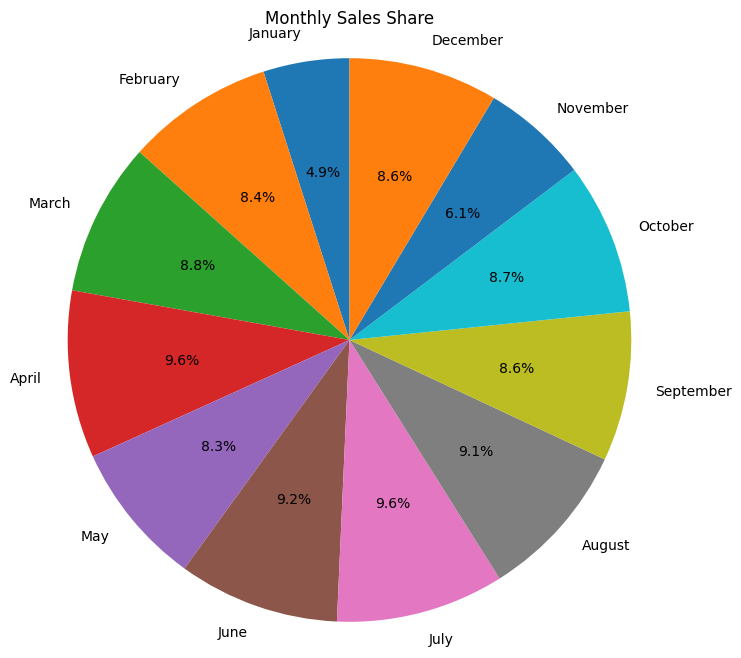

Quarterly roll-up


,Year,Quarter,Total_Sales,Average_Sales,Total_MarkDown
0,2010,1,"372,252,785.540","15,755.398",0.000
1,2010,2,"610,369,474.750","16,049.684",0.000
2,2010,3,"597,488,133.240","15,769.851",0.000
3,2010,4,"708,775,726.880","17,230.897",0.000
4,2011,1,"529,391,742.990","15,018.632",0.000
5,2011,2,"597,948,054.320","15,616.706",0.000
6,2011,3,"639,358,469.540","15,538.398",0.000
7,2011,4,"681,501,740.500","17,578.976","641,383,369.460"
8,2012,1,"592,467,701.690","15,330.635","936,508,655.320"
9,2012,2,"618,297,714.690","16,074.712","508,594,979.830"


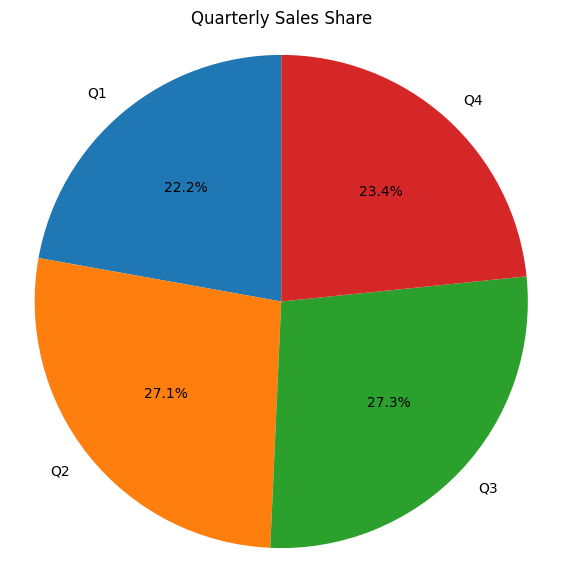

Store roll-up


,Store,Total_Sales,Average_Sales,Departments
19,20,"301,397,792.460","29,508.302",78
3,4,"299,543,953.380","29,161.210",78
13,14,"288,999,911.340","28,784.852",77
12,13,"286,517,703.800","27,355.137",79
1,2,"275,382,440.980","26,898.070",78
9,10,"271,617,713.890","26,332.304",77
26,27,"253,855,916.880","24,826.985",78
5,6,"223,756,130.640","21,913.244",77
0,1,"222,402,808.850","21,710.544",77
38,39,"207,445,542.470","21,000.764",75


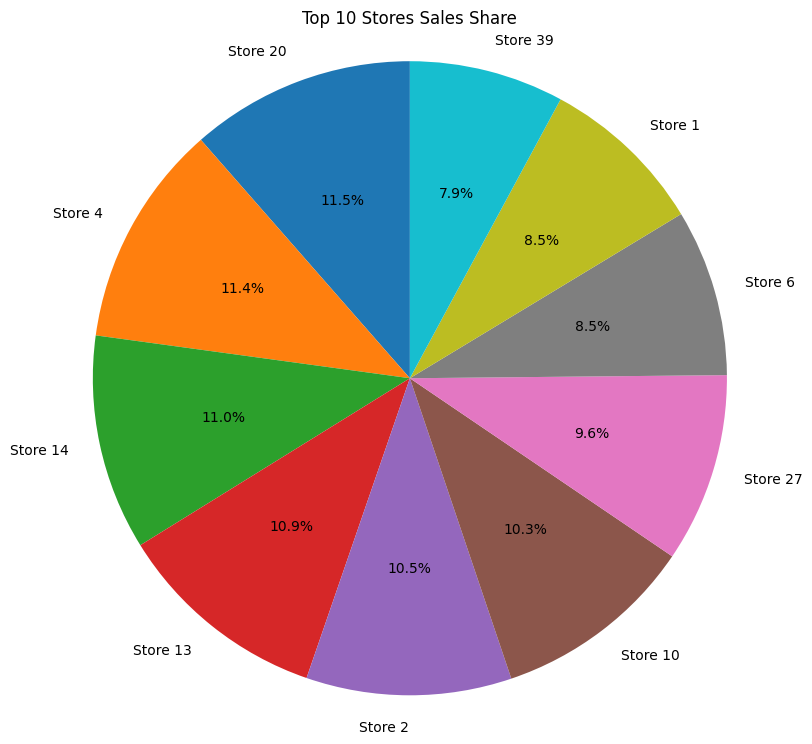

In [62]:
monthly_rollup = data.groupby(["Year", "Month", "Month_Name"], as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Total_MarkDown=("Total_MarkDown", "sum")
).sort_values(["Year", "Month"])

quarterly_rollup = data.groupby(["Year", "Quarter"], as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Total_MarkDown=("Total_MarkDown", "sum")
).sort_values(["Year", "Quarter"])

store_rollup = data.groupby("Store", as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Departments=("Dept", "nunique")
).sort_values("Total_Sales", ascending=False)

print("Monthly roll-up")
display(monthly_rollup.head(12))

# -----------------------------
# 1. Monthly Sales Share Pie Chart
# -----------------------------

monthly_pie = (
    monthly_rollup.groupby(["Month", "Month_Name"], as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Month")
)

plt.figure(figsize=(8, 8))
plt.pie(
    monthly_pie["Total_Sales"],
    labels=monthly_pie["Month_Name"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Monthly Sales Share")
plt.axis("equal")
plt.show()

print("Quarterly roll-up")
display(quarterly_rollup)

# -----------------------------
# 2. Quarterly Sales Share Pie Chart
# -----------------------------

quarterly_pie = (
    quarterly_rollup.groupby("Quarter", as_index=False)["Total_Sales"]
    .sum()
    .sort_values("Quarter")
)

quarterly_pie["Quarter_Label"] = "Q" + quarterly_pie["Quarter"].astype(str)

plt.figure(figsize=(7, 7))
plt.pie(
    quarterly_pie["Total_Sales"],
    labels=quarterly_pie["Quarter_Label"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Quarterly Sales Share")
plt.axis("equal")
plt.show()

print("Store roll-up")
display(store_rollup.head(10))

# -----------------------------
# 3. Top 10 Stores Sales Share Pie Chart
# -----------------------------

top10_store_pie = store_rollup.head(10).copy()
top10_store_pie["Store_Label"] = "Store " + top10_store_pie["Store"].astype(str)

plt.figure(figsize=(9, 9))
plt.pie(
    top10_store_pie["Total_Sales"],
    labels=top10_store_pie["Store_Label"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 10 Stores Sales Share")
plt.axis("equal")
plt.show()

### DSS Interpretation: Monthly Sales Share

The monthly sales share chart shows how total sales are distributed across the months.

Key observations:

- April and July have the highest sales share at around 9.6%.
- June and August also show strong sales contribution.
- January has the lowest sales share at around 4.9%.
- November has a lower share than expected compared with other months.

Business meaning:

Sales are not equally distributed across the year. Some months generate higher revenue and should receive more inventory, staffing, and promotion planning.

DSS recommendation:

Management should focus on high-sales months such as April, June, July, and August by increasing stock availability and preparing stronger operational plans.

For low-sales months such as January and November, the DSS recommends reviewing promotions, customer demand, and department-level performance to improve sales.

### DSS Interpretation: Quarterly Sales Share

The quarterly sales share chart shows the contribution of each quarter to total sales.

Key observations:

- Q3 has the highest sales share at around 27.3%.
- Q2 is very close to Q3 with around 27.1%.
- Q4 contributes around 23.4%.
- Q1 has the lowest sales share at around 22.2%.

Business meaning:

Q2 and Q3 are the strongest sales periods. This means customer demand is higher during the middle of the year.

DSS recommendation:

Management should allocate more inventory, staff, and marketing budget to Q2 and Q3 because they generate the largest share of revenue.

Q1 needs further analysis because it has the lowest sales contribution. The DSS recommends checking department performance, holiday effect, and promotion effectiveness during this period.

### DSS Interpretation: Top 10 Stores Sales Share

The top 10 stores sales share chart shows how sales are distributed among the best-performing stores.

Key observations:

- Store 20 has the highest share among the top 10 stores at around 11.5%.
- Store 4, Store 14, and Store 13 also show strong sales contribution.
- The top stores have close sales percentages, which means sales are distributed across several strong branches.
- Store 39 has the lowest share among the top 10 stores at around 7.9%.

Business meaning:

Some stores contribute more to total revenue than others. These stores are important for business performance and should receive priority in planning.

DSS recommendation:

Management should study the best-performing stores such as Store 20, Store 4, Store 14, and Store 13 to understand what drives their strong sales.

The DSS recommends using these stores as benchmarks for weaker stores.

For stores with lower shares inside the top 10, management should review department mix, store size, local demand, and promotion effectiveness.

---

# 15. OLAP Drill-down

Drill-down moves from summary to detail.

Examples:

- Year to Month to Week
- Store to Department

Business meaning:

If total sales drop, drill-down helps identify the exact month, week, store, or department causing the issue.

In [16]:
weekly_drilldown = data.groupby(["Year", "Month", "Week"], as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean")
).sort_values(["Year", "Month", "Week"])

store_dept_drilldown = data.groupby(["Store", "Dept"], as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Total_Drop=("Sales_Drop", "sum"),
    Avg_Performance=("Sales_Performance", "mean")
).sort_values("Total_Sales", ascending=False)

print("Weekly drill-down")
display(weekly_drilldown.head(15))

print("Store and department drill-down")
display(store_dept_drilldown.head(15))

Weekly drill-down


,Year,Month,Week,Total_Sales,Average_Sales
0,2010,2,5,"49,750,740.500","16,836.122"
1,2010,2,6,"48,336,677.630","16,352.056"
2,2010,2,7,"48,276,993.780","16,216.659"
3,2010,2,8,"43,968,571.130","14,899.550"
4,2010,3,9,"46,871,470.300","15,921.016"
5,2010,3,10,"45,925,396.510","15,546.851"
6,2010,3,11,"44,988,974.640","15,286.774"
7,2010,3,12,"44,133,961.050","14,975.894"
8,2010,4,13,"50,423,831.260","17,098.620"
9,2010,4,14,"47,365,290.440","16,050.590"


Store and department drill-down


,Store,Dept,Total_Sales,Average_Sales,Total_Drop,Avg_Performance
1057,14,92,"26,101,497.710","182,527.956","1,671,734.680",1.000
147,2,92,"23,572,153.030","164,840.231","987,074.250",1.000
1523,20,92,"23,542,625.040","164,633.742","1,311,994.100",1.000
980,13,92,"23,170,876.200","162,034.099","800,651.800",1.000
297,4,92,"22,789,210.430","159,365.108","946,646.820",1.000
1526,20,95,"21,537,795.620","150,613.955","783,543.370",1.000
300,4,95,"21,054,815.740","147,236.474","543,618.610",1.000
2061,27,92,"20,952,094.220","146,518.141","886,919.480",1.000
1060,14,95,"20,655,911.350","144,446.933","931,021.910",1.000
150,2,95,"20,533,191.520","143,588.752","517,812.650",1.000


---

# 16. OLAP Slice

Slice selects one value from one dimension.

We create two slices:

- Store 1 only
- Holiday weeks only

Business meaning:

Slice helps managers focus on one branch or one business scenario.

In [17]:
slice_store_1 = data[data["Store"] == 1]
slice_holiday = data[data["IsHoliday"] == True]

print("Store 1 slice shape:", slice_store_1.shape)
print("Holiday slice shape:", slice_holiday.shape)

print("Store 1 sales by department")
display(slice_store_1.groupby("Dept", as_index=False)["Weekly_Sales"].sum().sort_values("Weekly_Sales", ascending=False).head(10))

print("Holiday sales by store")
display(slice_holiday.groupby("Store", as_index=False)["Weekly_Sales"].sum().sort_values("Weekly_Sales", ascending=False).head(10))

Store 1 slice shape: (10244, 32)
Holiday slice shape: (29661, 32)
Store 1 sales by department


,Dept,Weekly_Sales
69,92,"19,370,632.640"
72,95,"17,270,404.890"
67,90,"11,787,139.340"
36,38,"11,436,885.830"
70,93,"10,252,983.080"
68,91,"9,186,168.910"
71,94,"9,034,821.250"
37,40,"8,366,988.510"
56,72,"6,776,862.220"
1,2,"6,592,598.930"


Holiday sales by store


,Store,Weekly_Sales
19,20,"22,490,350.810"
3,4,"22,431,026.240"
13,14,"21,205,829.980"
9,10,"21,137,559.490"
12,13,"21,130,438.060"
1,2,"20,792,669.000"
26,27,"18,922,992.780"
5,6,"16,809,079.270"
0,1,"16,657,476.560"
18,19,"15,770,467.340"


---

# 17. OLAP Dice

Dice selects multiple values from multiple dimensions.

Here we analyze:

- Stores 1 to 5
- Departments 1 to 10
- Holiday weeks only

Business meaning:

Dice supports focused comparison across selected stores, departments, and seasonal periods.

In [18]:
dice_data = data[
    (data["Store"].isin([1, 2, 3, 4, 5])) &
    (data["Dept"].between(1, 10)) &
    (data["IsHoliday"] == True)
]

dice_summary = dice_data.groupby(["Store", "Dept"], as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Total_MarkDown=("Total_MarkDown", "sum")
).sort_values("Total_Sales", ascending=False)

print("Dice data shape:", dice_data.shape)
display(dice_summary.head(20))

Dice data shape: (500, 32)


,Store,Dept,Total_Sales,Average_Sales,Total_MarkDown
31,4,2,"915,024.770","91,502.477","242,013.570"
11,2,2,"642,808.430","64,280.843","246,611.090"
34,4,5,"624,117.720","62,411.772","242,013.570"
36,4,7,"621,145.370","62,114.537","242,013.570"
37,4,8,"620,362.290","62,036.229","242,013.570"
33,4,4,"593,224.920","59,322.492","242,013.570"
17,2,8,"587,528.210","58,752.821","246,611.090"
16,2,7,"531,479.630","53,147.963","246,611.090"
13,2,4,"489,923.410","48,992.341","246,611.090"
14,2,5,"461,454.320","46,145.432","246,611.090"


---

# 18. OLAP Pivot

A pivot table reshapes the data.

This pivot shows:

- Rows as stores
- Columns as months
- Values as total weekly sales

Business meaning:

Managers can compare sales seasonality for each store in one table.

In [19]:
store_month_pivot = data.pivot_table(
    values="Weekly_Sales",
    index="Store",
    columns="Month",
    aggfunc="sum",
    fill_value=0
)

display(store_month_pivot.head(10))

Month,1,2,3,4,5,6,7,8,9,10,11,12
Store,,,,,,,,,,,,
1,"11,203,741.490","19,505,306.580","20,380,666.860","21,623,140.340","18,505,332.900","20,299,636.040","20,706,084.020","20,118,558.270","19,331,717.780","19,468,556.790","13,350,519.890","17,909,547.890"
2,"13,865,921.820","24,373,245.290","24,721,386.450","26,332,735.330","22,694,865.990","25,329,262.390","25,694,961.540","24,635,105.830","23,119,921.760","23,779,347.160","16,868,736.460","23,966,950.960"
3,"2,955,998.920","5,203,003.940","5,297,398.080","5,532,990.610","4,714,555.710","5,211,643.260","5,277,448.520","5,020,547.120","4,920,143.010","5,037,413.330","3,570,895.380","4,844,697.190"
4,"15,351,874.470","26,202,900.830","26,533,976.510","28,087,636.670","24,391,698.260","26,823,653.800","27,978,994.510","27,105,227.930","26,110,370.450","26,713,015.050","18,633,084.090","25,611,520.810"
5,"2,288,417.130","3,847,050.180","4,068,693.680","4,528,814.030","3,825,411.030","4,169,038.030","4,196,455.390","3,997,294.650","3,972,545.150","3,927,010.350","2,894,288.450","3,760,670.830"
6,"10,586,373.350","18,470,361.050","20,317,796.350","21,925,974.830","18,362,954.550","21,617,752.820","22,621,081.660","20,009,363.070","18,257,456.910","18,302,920.500","13,621,071.000","19,663,024.550"
7,"4,669,494.420","6,628,546.760","7,364,221.820","6,608,424.050","5,235,816.380","7,757,134.570","9,222,795.360","8,214,814.000","7,030,833.480","6,465,672.150","4,915,268.380","7,485,253.770"
8,"6,569,545.120","11,707,440.470","11,529,918.850","12,580,462.370","10,674,184.050","11,716,011.930","11,905,378.610","11,714,558.380","11,125,355.920","11,439,969.020","7,983,206.100","11,005,150.310"
9,"3,823,783.160","6,693,516.110","6,915,253.530","7,583,158.460","6,537,369.230","7,203,335.900","7,093,655.580","6,926,997.310","6,640,608.690","6,876,571.840","4,876,207.440","6,618,761.740"


---

# 19. DSS Visualization Setup

We create helper functions for readable charts and DSS interpretation.

Each chart is followed by a practical business explanation.

In [20]:
def print_dss(title, points):
    print(title)
    for point in points:
        print("-", point)


def top_bottom_text(df, label_col, value_col):
    top_row = df.sort_values(value_col, ascending=False).iloc[0]
    bottom_row = df.sort_values(value_col, ascending=True).iloc[0]
    return top_row, bottom_row

plot_sample = data.sample(n=min(8000, len(data)), random_state=42)

## Visualization 2: Total sales by store

DSS interpretation:

- High-sales stores may need stronger stock planning.
- Low-sales stores may need store-level review.
- This view supports resource allocation by branch.

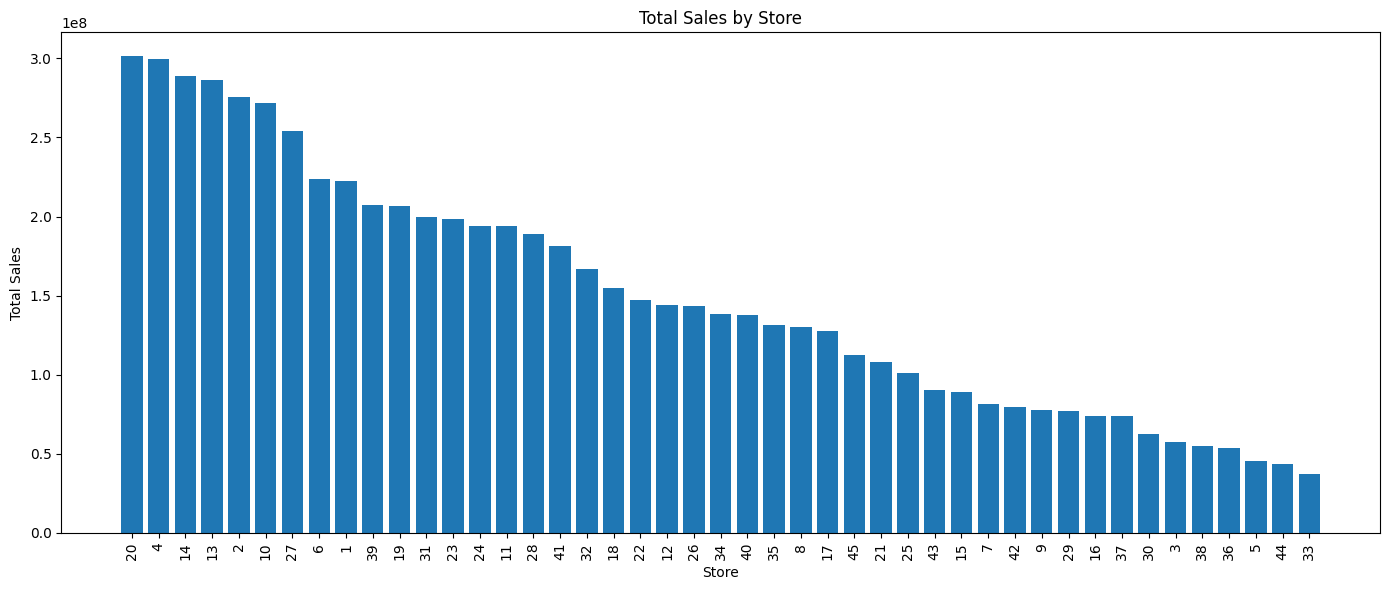

DSS interpretation
- Store 20 has the highest total sales.
- Store 33 has the lowest total sales.
- Management should compare low-performing stores with stores of the same type and size.


In [21]:
store_sales = data.groupby("Store", as_index=False)["Weekly_Sales"].sum().sort_values("Weekly_Sales", ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(store_sales["Store"].astype(str), store_sales["Weekly_Sales"])
plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

top_store, bottom_store = top_bottom_text(store_sales, "Store", "Weekly_Sales")
print_dss("DSS interpretation", [
    f"Store {int(top_store['Store'])} has the highest total sales.",
    f"Store {int(bottom_store['Store'])} has the lowest total sales.",
    "Management should compare low-performing stores with stores of the same type and size."
])

### DSS Interpretation: Total Sales by Store

The chart shows clear sales differences between Walmart stores.

Key observations:

- Store 20 has the highest total sales.
- Stores 4, 14, 13, 2, 10, and 27 are also strong performers.
- Stores 33, 44, 5, 36, and 38 have the lowest sales.
- Sales are not evenly distributed across stores.

Business meaning:

Some stores generate much higher revenue than others. This may be related to store size, store type, location, customer demand, or department performance.

DSS recommendation:

Management should use high-performing stores as benchmarks.

Low-performing stores need deeper analysis by department, holiday impact, markdown effectiveness, and local economic conditions before making inventory or promotion decisions.

---

## Visualization 3: Total sales by department

DSS interpretation:

- Strong departments may need inventory protection.
- Weak departments may need promotion, layout, or pricing review.
- Department analysis is important because the same store can contain both strong and weak areas.

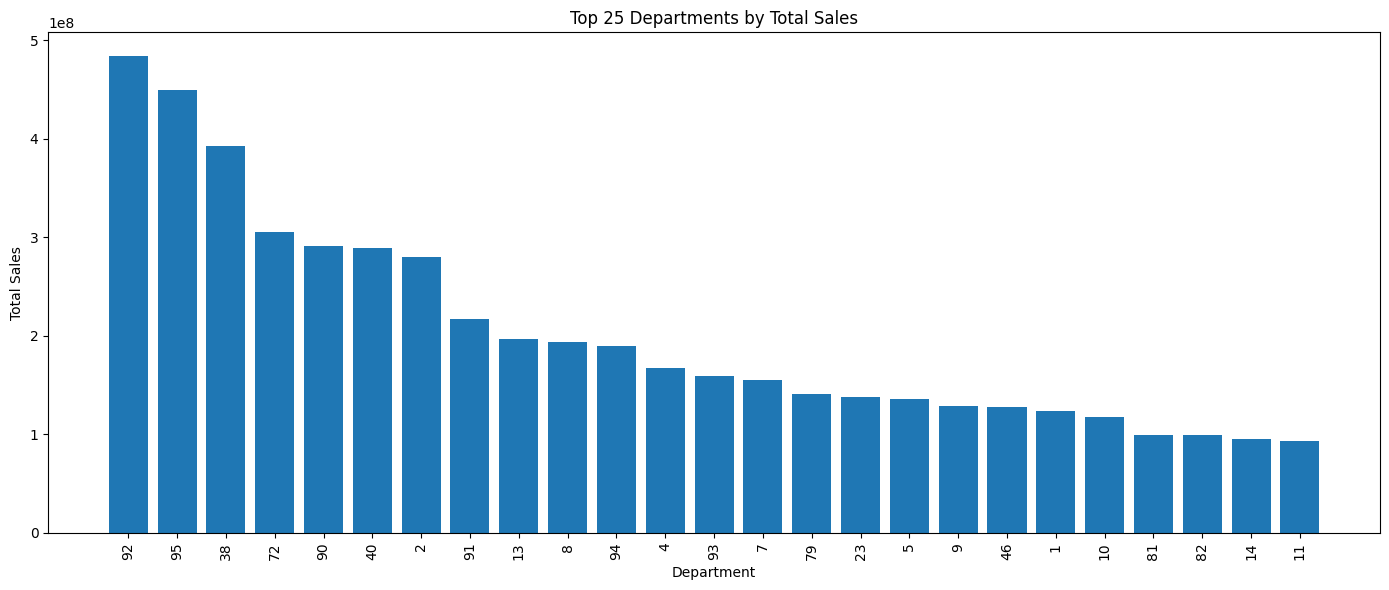

DSS interpretation
- Department 92 has the highest total sales.
- Department 47 has the lowest total sales.
- Weak departments should be reviewed by store type before applying one general action.


In [22]:
dept_sales = data.groupby("Dept", as_index=False)["Weekly_Sales"].sum().sort_values("Weekly_Sales", ascending=False)

top_n = dept_sales.head(25)

plt.figure(figsize=(14, 6))
plt.bar(top_n["Dept"].astype(str), top_n["Weekly_Sales"])
plt.title("Top 25 Departments by Total Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

top_dept, bottom_dept = top_bottom_text(dept_sales, "Dept", "Weekly_Sales")
print_dss("DSS interpretation", [
    f"Department {int(top_dept['Dept'])} has the highest total sales.",
    f"Department {int(bottom_dept['Dept'])} has the lowest total sales.",
    "Weak departments should be reviewed by store type before applying one general action."
])

### DSS Interpretation: Top 25 Departments by Total Sales

The chart shows that sales are concentrated in a limited number of departments.

Key observations:

- Department 92 has the highest total sales.
- Departments 95 and 38 are also strong revenue drivers.
- There is a clear drop after the top 3 departments.
- The lower departments in the chart contribute less compared with the leading departments.

Business meaning:

Some departments generate a large part of Walmart revenue. These departments are critical for inventory planning and sales performance.

DSS recommendation:

Management should give high priority to top departments such as 92, 95, and 38.

These departments need strong stock availability, regular demand monitoring, and focused promotion planning.

Lower-performing departments should be reviewed to understand if the issue is demand, pricing, store placement, or promotion effectiveness.

---

## Visualization 4: Monthly sales trend

DSS interpretation:

- This chart reveals seasonal behavior.
- Peaks can indicate strong demand periods.
- Drops can indicate periods that need campaigns or stock control.

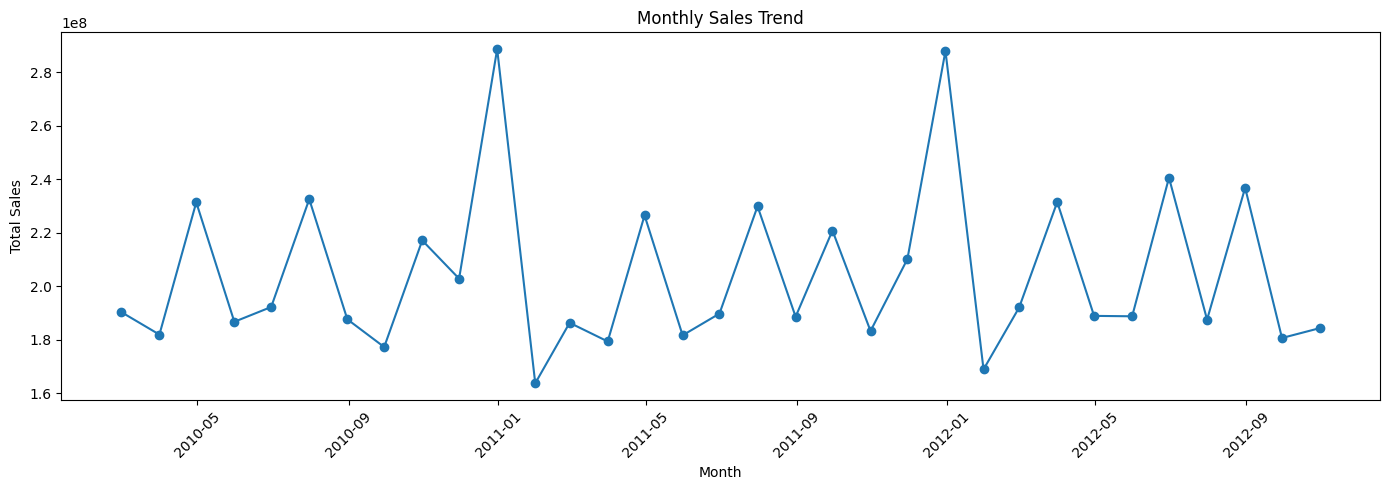

DSS interpretation
- Highest sales month is 2010-12.
- Lowest sales month is 2011-01.
- Planning should be based on monthly seasonality, not only total annual sales.


In [23]:
monthly_trend = data.groupby(pd.Grouper(key="Date", freq="M"), as_index=True)["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend["Date"], monthly_trend["Weekly_Sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_month = monthly_trend.loc[monthly_trend["Weekly_Sales"].idxmax()]
weak_month = monthly_trend.loc[monthly_trend["Weekly_Sales"].idxmin()]
print_dss("DSS interpretation", [
    f"Highest sales month is {best_month['Date'].strftime('%Y-%m')}.",
    f"Lowest sales month is {weak_month['Date'].strftime('%Y-%m')}.",
    "Planning should be based on monthly seasonality, not only total annual sales."
])

### DSS Interpretation: Monthly Sales Trend

The chart shows monthly sales changes over time from 2010 to 2012.

Key observations:

- Sales show repeated peaks at the beginning of 2011 and 2012.
- The highest sales points appear around January in both 2011 and 2012.
- Sales drop sharply after these peaks.
- The trend is not stable across months.

Business meaning:

Walmart sales are affected by seasonality and time-based demand changes.

Some months require higher inventory and stronger operational planning, while other months need promotion support.

DSS recommendation:

Management should prepare early for peak months by increasing stock levels, staffing, and supply chain readiness.

For months after sharp drops, the DSS recommends reviewing promotions, department demand, and holiday effects to reduce sales decline.

---

## Visualization 5: Weekly sales trend

DSS interpretation:

- Weekly analysis gives finer detail than monthly analysis.
- It helps detect short-term sales changes.
- It supports fast tactical decisions.

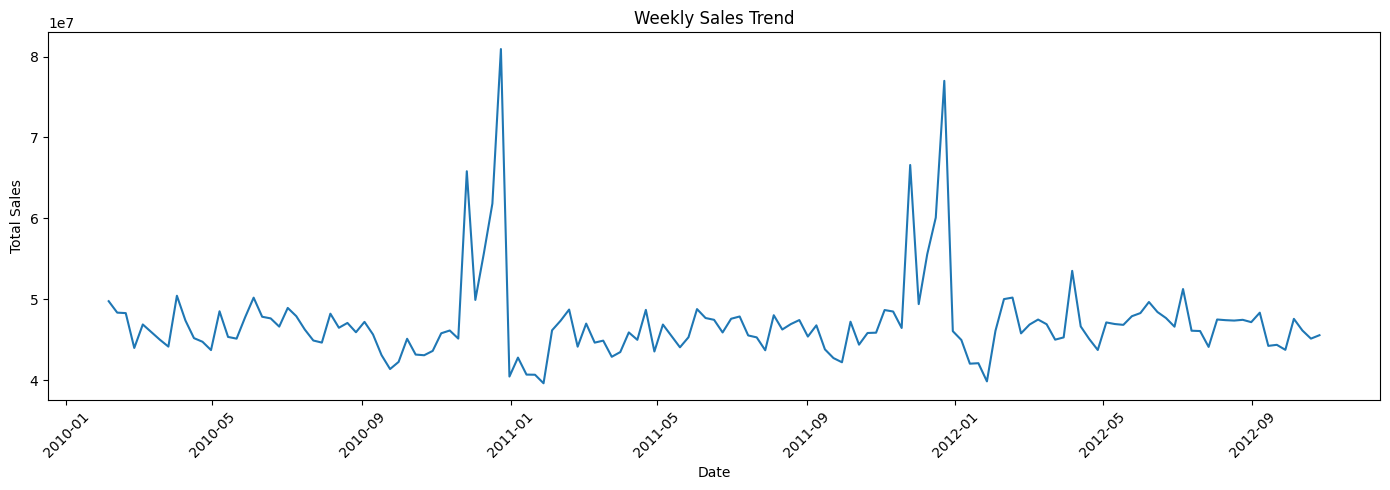

DSS interpretation
- Highest sales week starts on 2010-12-24.
- Lowest sales week starts on 2011-01-28.
- Weekly drops should be checked against holidays and markdowns.


In [24]:
weekly_trend = data.groupby("Date", as_index=False)["Weekly_Sales"].sum().sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(weekly_trend["Date"], weekly_trend["Weekly_Sales"])
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_week = weekly_trend.loc[weekly_trend["Weekly_Sales"].idxmax()]
weak_week = weekly_trend.loc[weekly_trend["Weekly_Sales"].idxmin()]
print_dss("DSS interpretation", [
    f"Highest sales week starts on {best_week['Date'].date()}.",
    f"Lowest sales week starts on {weak_week['Date'].date()}.",
    "Weekly drops should be checked against holidays and markdowns."
])

---

## Visualization 6: Holiday vs non-holiday average sales

DSS interpretation:

- This chart compares seasonal sales behavior.
- If holiday sales are higher, holiday planning is important.
- If holiday sales are not higher, promotion effectiveness needs review.

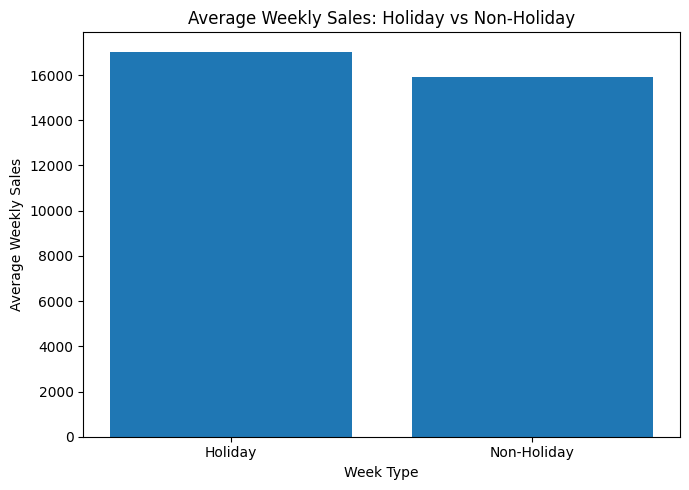

,Holiday_Label,Weekly_Sales
0,Holiday,"17,035.823"
1,Non-Holiday,"15,901.445"


DSS interpretation
- Average holiday sales difference is 1,134.38 compared with non-holiday weeks.
- Holiday strategy should be tested by department because not all departments react the same way.
- A high holiday average supports stronger seasonal inventory planning.


In [25]:
holiday_avg = data.groupby("Holiday_Label", as_index=False)["Weekly_Sales"].mean().sort_values("Weekly_Sales", ascending=False)

plt.figure(figsize=(7, 5))
plt.bar(holiday_avg["Holiday_Label"], holiday_avg["Weekly_Sales"])
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")
plt.tight_layout()
plt.show()

display(holiday_avg)

if len(holiday_avg) == 2:
    holiday_value = holiday_avg.loc[holiday_avg["Holiday_Label"] == "Holiday", "Weekly_Sales"].values[0]
    non_holiday_value = holiday_avg.loc[holiday_avg["Holiday_Label"] == "Non-Holiday", "Weekly_Sales"].values[0]
    difference = holiday_value - non_holiday_value
    print_dss("DSS interpretation", [
        f"Average holiday sales difference is {difference:,.2f} compared with non-holiday weeks.",
        "Holiday strategy should be tested by department because not all departments react the same way.",
        "A high holiday average supports stronger seasonal inventory planning."
    ])

---

## Visualization 7: Sales by store type

DSS interpretation:

- Store type can explain structural differences in sales.
- Comparing store types helps avoid unfair comparison between different store formats.

,Type,Total_Sales,Average_Sales,Stores
0,A,"4,331,014,722.750","20,099.568",22
1,B,"2,000,700,736.820","12,237.076",17
2,C,"405,503,527.540","9,519.533",6


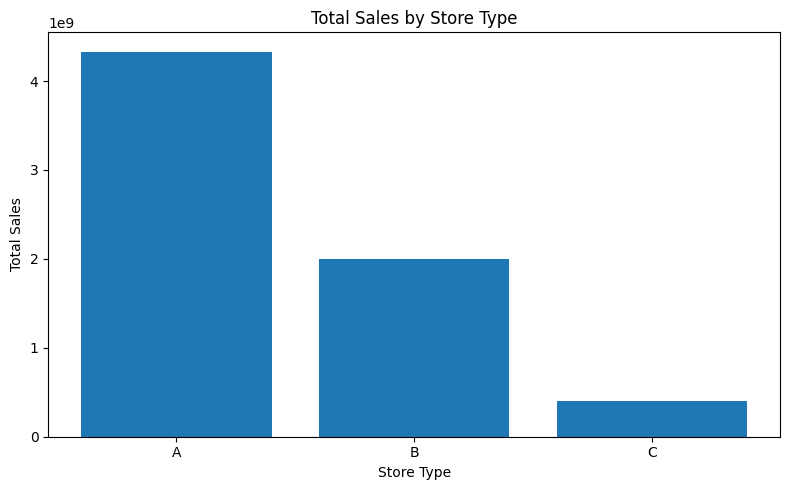

DSS interpretation
- Store type A has the highest total sales.
- Store type should be used as a dimension in DSS comparisons.
- Managers should compare stores within the same type before taking action.


In [26]:
type_sales = data.groupby("Type", as_index=False).agg(
    Total_Sales=("Weekly_Sales", "sum"),
    Average_Sales=("Weekly_Sales", "mean"),
    Stores=("Store", "nunique")
).sort_values("Total_Sales", ascending=False)

display(type_sales)

plt.figure(figsize=(8, 5))
plt.bar(type_sales["Type"], type_sales["Total_Sales"])
plt.title("Total Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

best_type = type_sales.iloc[0]
print_dss("DSS interpretation", [
    f"Store type {best_type['Type']} has the highest total sales.",
    "Store type should be used as a dimension in DSS comparisons.",
    "Managers should compare stores within the same type before taking action."
])

### DSS Interpretation: Total Sales by Store Type

The chart shows total sales by Walmart store type.

Key observations:

- Store Type A has the highest total sales.
- Store Type B comes second with lower sales than Type A.
- Store Type C has the lowest total sales.
- Sales performance differs clearly by store type.

Business meaning:

Store type has a strong effect on total sales. Type A stores appear to be the main revenue drivers.

DSS recommendation:

Management should prioritize Type A stores for inventory, staffing, and promotion planning because they generate the largest sales volume.

Type B and Type C stores need further analysis to understand whether lower sales are caused by store size, location, department mix, or local demand.

---

## Visualization 8: Store size vs total sales

DSS interpretation:

- This chart checks whether larger stores generate higher sales.
- Outliers can reveal large stores with weak sales or small stores with strong performance.

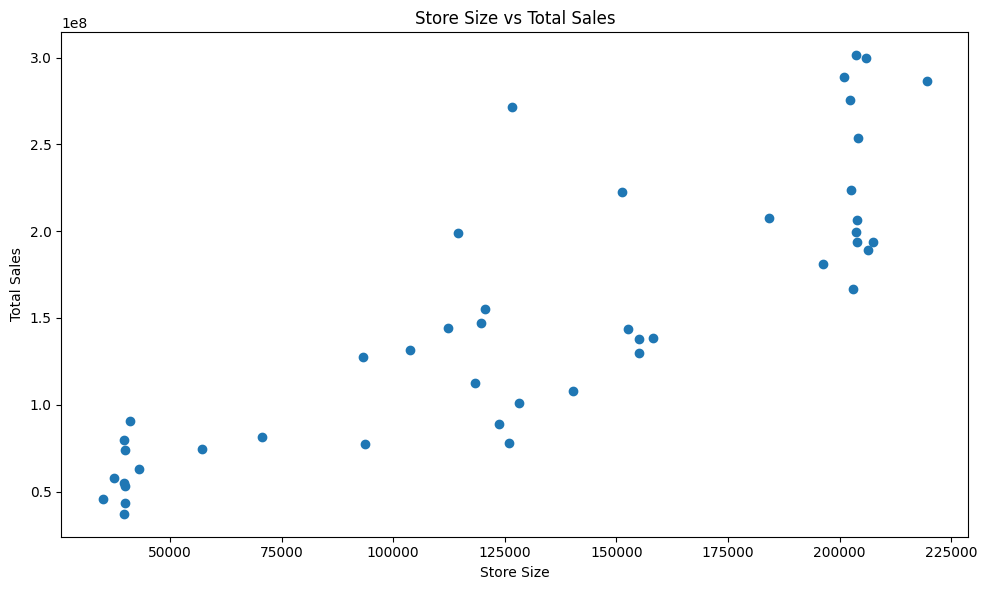

DSS interpretation
- Correlation between store size and total sales is 0.846.
- A strong positive value means larger stores usually sell more.
- Weak or negative correlation means management should investigate operational differences.


In [27]:
size_sales = data.groupby(["Store", "Size", "Type"], as_index=False)["Weekly_Sales"].sum()

plt.figure(figsize=(10, 6))
plt.scatter(size_sales["Size"], size_sales["Weekly_Sales"])
plt.title("Store Size vs Total Sales")
plt.xlabel("Store Size")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

corr_size_sales = size_sales["Size"].corr(size_sales["Weekly_Sales"])
print_dss("DSS interpretation", [
    f"Correlation between store size and total sales is {corr_size_sales:.3f}.",
    "A strong positive value means larger stores usually sell more.",
    "Weak or negative correlation means management should investigate operational differences."
])

---

## Visualization 9: Total markdown vs weekly sales

DSS interpretation:

- This chart checks whether higher markdowns are associated with higher sales.
- If high markdown does not increase sales, promotions may be weak.

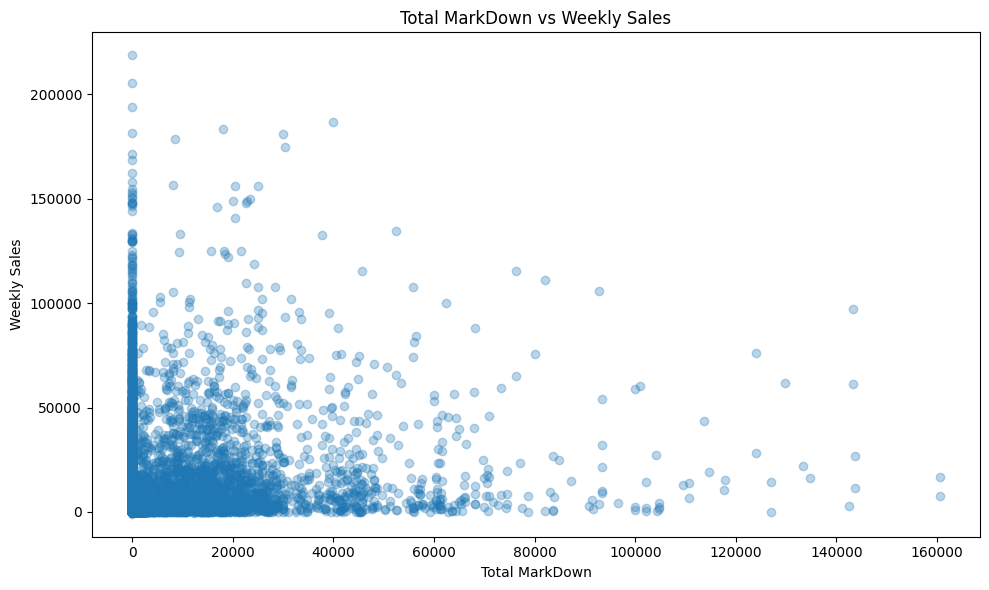

DSS interpretation
- Correlation between total markdown and weekly sales is 0.065.
- Low correlation means markdowns do not always produce strong sales.
- Promotion decisions should be evaluated by department, not only by total markdown amount.


In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(plot_sample["Total_MarkDown"], plot_sample["Weekly_Sales"], alpha=0.3)
plt.title("Total MarkDown vs Weekly Sales")
plt.xlabel("Total MarkDown")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

corr_markdown_sales = data["Total_MarkDown"].corr(data["Weekly_Sales"])
print_dss("DSS interpretation", [
    f"Correlation between total markdown and weekly sales is {corr_markdown_sales:.3f}.",
    "Low correlation means markdowns do not always produce strong sales.",
    "Promotion decisions should be evaluated by department, not only by total markdown amount."
])

---

## Visualization 10: CPI vs weekly sales

DSS interpretation:

- CPI represents price level pressure.
- This chart checks whether sales change when CPI changes.

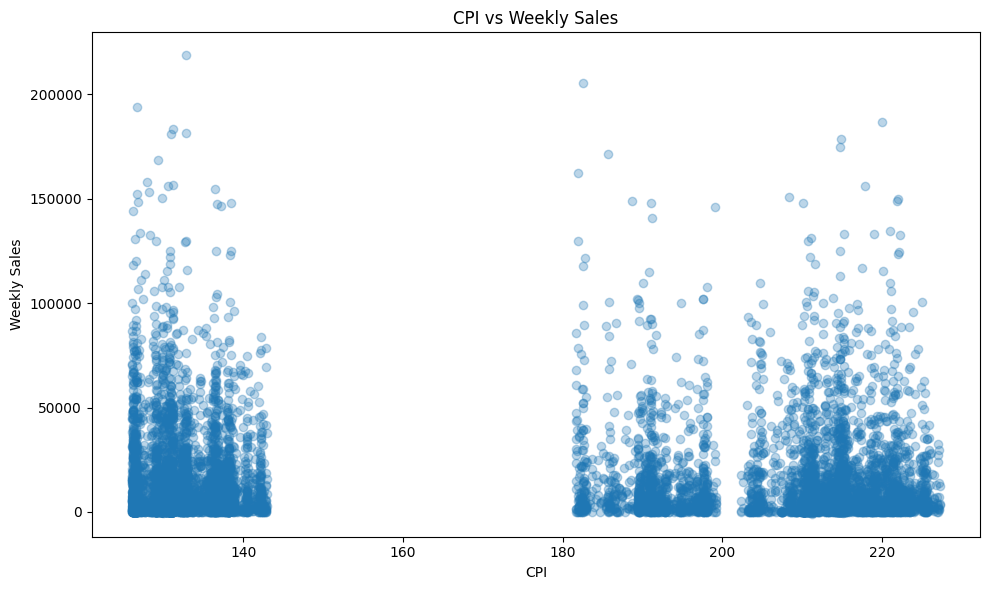

DSS interpretation
- Correlation between CPI and weekly sales is -0.021.
- Economic indicators should support the DSS, but they should not be used alone.
- Store and department context is still required.


In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(plot_sample["CPI"], plot_sample["Weekly_Sales"], alpha=0.3)
plt.title("CPI vs Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

corr_cpi_sales = data["CPI"].corr(data["Weekly_Sales"])
print_dss("DSS interpretation", [
    f"Correlation between CPI and weekly sales is {corr_cpi_sales:.3f}.",
    "Economic indicators should support the DSS, but they should not be used alone.",
    "Store and department context is still required."
])

---

## Visualization 11: Unemployment vs weekly sales

DSS interpretation:

- Unemployment can reflect customer purchasing pressure.
- High unemployment areas may need different pricing or promotion strategies.

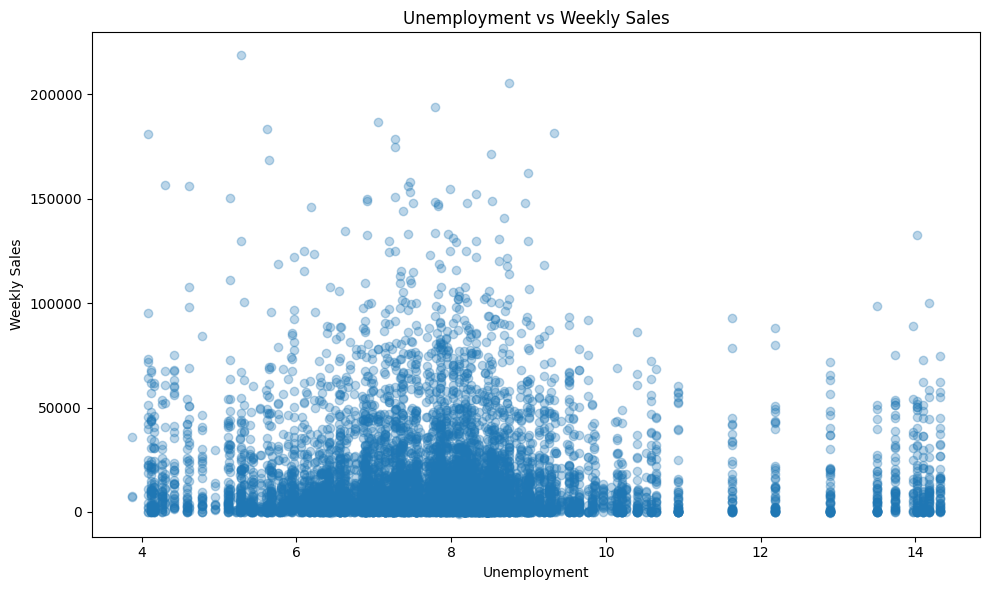

DSS interpretation
- Correlation between unemployment and weekly sales is -0.026.
- High unemployment can be used as a risk factor in fuzzy logic.
- The DSS should combine unemployment with actual sales performance.


In [30]:
plt.figure(figsize=(10, 6))
plt.scatter(plot_sample["Unemployment"], plot_sample["Weekly_Sales"], alpha=0.3)
plt.title("Unemployment vs Weekly Sales")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.tight_layout()
plt.show()

corr_unemp_sales = data["Unemployment"].corr(data["Weekly_Sales"])
print_dss("DSS interpretation", [
    f"Correlation between unemployment and weekly sales is {corr_unemp_sales:.3f}.",
    "High unemployment can be used as a risk factor in fuzzy logic.",
    "The DSS should combine unemployment with actual sales performance."
])

---

## Visualization 12: Store and month sales heatmap

DSS interpretation:

- The heatmap shows store-month concentration.
- Darker cells represent stronger sales.
- Managers can identify store seasonality quickly.

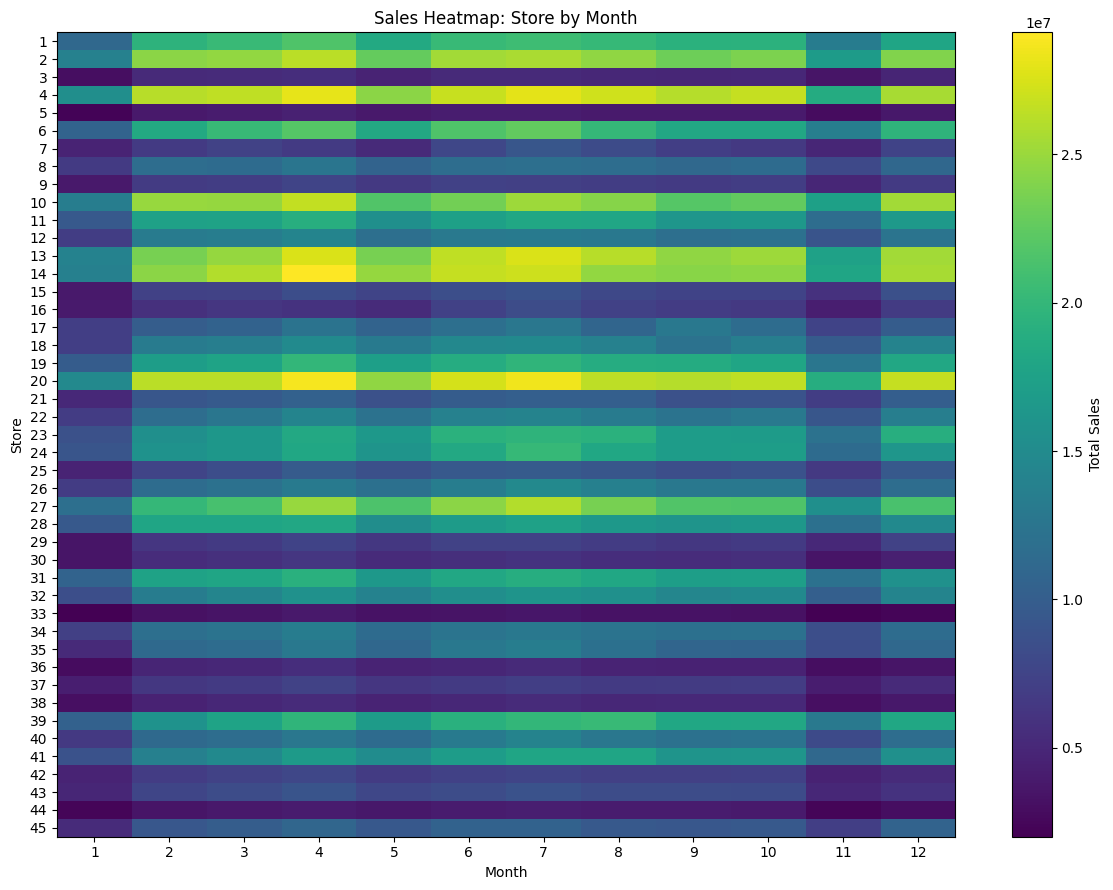

DSS interpretation
- The heatmap helps compare seasonal sales across stores.
- Stores with consistently low cells need review.
- Stores with seasonal peaks need earlier inventory planning.


In [31]:
heatmap_data = store_month_pivot.copy()

plt.figure(figsize=(12, 9))
plt.imshow(heatmap_data, aspect="auto")
plt.title("Sales Heatmap: Store by Month")
plt.xlabel("Month")
plt.ylabel("Store")
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns)
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index)
plt.colorbar(label="Total Sales")
plt.tight_layout()
plt.show()

print_dss("DSS interpretation", [
    "The heatmap helps compare seasonal sales across stores.",
    "Stores with consistently low cells need review.",
    "Stores with seasonal peaks need earlier inventory planning."
])

### DSS Interpretation: Sales Heatmap by Store and Month

The heatmap shows sales intensity for each store across months.

Key observations:

- Stores 4, 13, 20, and 27 show strong sales across several months.
- Sales are higher in months 3, 4, 6, 7, 9, 10, and 12 for many stores.
- Stores 33, 36, 37, and 44 show lower sales intensity across most months.
- Some stores have stable performance, while others change clearly from month to month.

Business meaning:

Sales performance depends on both store and month. This means store-level planning should not use one fixed strategy for the full year.

DSS recommendation:

Management should give high-performing store-month combinations priority in inventory and staffing.

Low-performing store-month combinations need deeper review.

The DSS recommends checking department sales, markdown effectiveness, holiday impact, and local economic conditions before changing promotion or stock plans.

---

## Visualization 13: Sales performance distribution

DSS interpretation:

- Sales_Performance around 1 means sales are near the normal average for the same store and department.
- Values below 1 mean weaker performance.
- Values above 1 mean stronger performance.

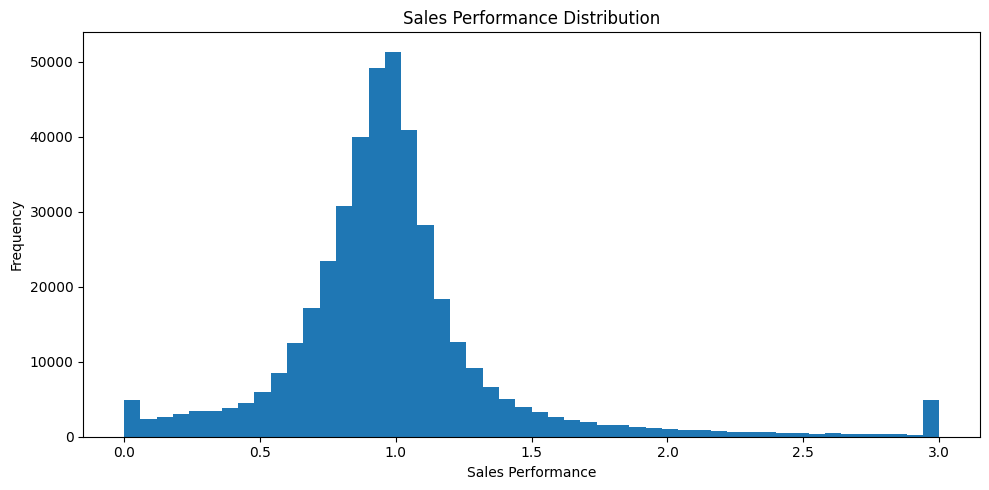

DSS interpretation
- A value below 1 indicates underperformance against the normal store-department average.
- A value near 1 indicates normal sales behavior.
- This feature is useful as a fuzzy logic input.


In [32]:
performance_plot = data["Sales_Performance"].replace([np.inf, -np.inf], np.nan).dropna().clip(0, 3)

plt.figure(figsize=(10, 5))
plt.hist(performance_plot, bins=50)
plt.title("Sales Performance Distribution")
plt.xlabel("Sales Performance")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print_dss("DSS interpretation", [
    "A value below 1 indicates underperformance against the normal store-department average.",
    "A value near 1 indicates normal sales behavior.",
    "This feature is useful as a fuzzy logic input."
])

### DSS Interpretation: Sales Performance Distribution

The chart shows how sales performance values are distributed across the dataset.

Key observations:

- Most records are concentrated around 1.0.
- A value near 1.0 means sales are close to the normal average for the same store and department.
- Values below 1.0 indicate weaker-than-normal sales performance.
- Values above 1.0 indicate stronger-than-normal sales performance.
- A small number of records are close to 3.0, which means very strong performance compared with the normal level.

Business meaning:

Most store-department combinations perform near their expected sales level, but some records show clear underperformance or overperformance.

DSS recommendation:

Management should focus on records with sales performance below 1.0 because they may indicate sales risk.

Records above 1.5 should be studied to understand successful patterns that can be repeated in other stores or departments.

---

# 20. Fuzzy Logic Sales Risk DSS

We build a fuzzy DSS that estimates sales risk for each store-department combination.

### Fuzzy DSS Analysis Level

The fuzzy DSS is applied at the **Store + Department** level.

This means the system does not evaluate the whole store only.

It also does not evaluate the department across all stores only.

Instead, it evaluates each store-department combination separately.

Examples:

| Store | Department | Analysis Meaning |
|---|---:|---|
| Store 1 | Dept 5 | Risk for Department 5 inside Store 1 |
| Store 1 | Dept 10 | Risk for Department 10 inside Store 1 |
| Store 2 | Dept 5 | Risk for Department 5 inside Store 2 |
| Store 2 | Dept 10 | Risk for Department 10 inside Store 2 |
| Store 20 | Dept 92 | Risk for Department 92 inside Store 20 |
| Store 33 | Dept 45 | Risk for Department 45 inside Store 33 |

**Business meaning:**

The same department can perform well in one store and poorly in another store.

Also, the same store can have strong departments and weak departments.

So the DSS helps management answer this question:

**Which department inside which store needs attention?**

Example interpretation:

| Store | Department | Fuzzy Risk Level | DSS Meaning |
|---|---:|---|---|
| Store 20 | Dept 92 | Low Risk | Sales are stable and no urgent action is needed |
| Store 1 | Dept 10 | Medium Risk | Sales need monitoring and promotion review |
| Store 33 | Dept 45 | High Risk | Management should review sales, stock, and markdown strategy |

**DSS recommendation:**

The management should not make decisions only at the store level.

The better decision is to analyze each **Store + Department** pair.

This gives a more accurate view of sales risk and helps target actions to the exact weak area.

## Inputs

| Input | Business meaning |
|---|---|
| Sales_Performance | Relative performance against normal sales |
| Markdown_Intensity | How heavy promotions are compared with sales |
| Sales_Drop_Pct | Severity of sales drop compared with previous week |
| Unemployment | Economic pressure around the store |
| IsHoliday | Whether the week is seasonal |

## Output

| Output | Meaning |
|---|---|
| Fuzzy_Risk_Score | Crisp risk score from 0 to 100 |
| Risk_Label | Low, Medium, or High |
| Recommendation | DSS action for management |

# 21. Membership Functions

A membership function converts a numeric value into a fuzzy degree between 0 and 1.

Examples:

- Sales performance can be low, medium, or high.
- Markdown intensity can be low, medium, or high.
- Sales risk can be low, medium, or high.

The fuzzy system is transparent because every rule can be explained.

In [33]:
def triangular(x, a, b, c):
    """Triangular membership function."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    if b != a:
        left = (a < x) & (x < b)
        y[left] = (x[left] - a) / (b - a)

    y[x == b] = 1.0

    if c != b:
        right = (b < x) & (x < c)
        y[right] = (c - x[right]) / (c - b)

    return np.clip(y, 0, 1)


def trapezoid(x, a, b, c, d):
    """Trapezoidal membership function."""
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)

    if b != a:
        left = (a < x) & (x < b)
        y[left] = (x[left] - a) / (b - a)

    y[(b <= x) & (x <= c)] = 1.0

    if d != c:
        right = (c < x) & (x < d)
        y[right] = (d - x[right]) / (d - c)

    return np.clip(y, 0, 1)


def scalar_membership(value):
    """Return one scalar membership degree."""
    return float(np.asarray(value).reshape(-1)[0])


def centroid_defuzzification(x_range, aggregated_membership):
    """Calculate crisp score using centroid defuzzification."""
    total = np.sum(aggregated_membership)
    if total == 0:
        return 50.0
    return float(np.sum(x_range * aggregated_membership) / total)

---

## Plot membership functions

This section visualizes the fuzzy input and output sets.

DSS interpretation:

- The shapes show how business language is converted into numbers.
- Managers can review and change these boundaries if their business policy changes.

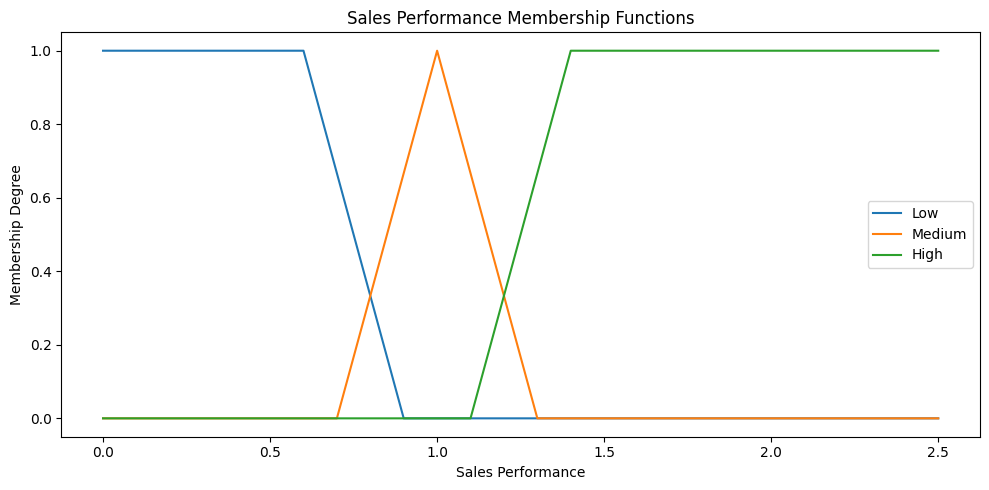

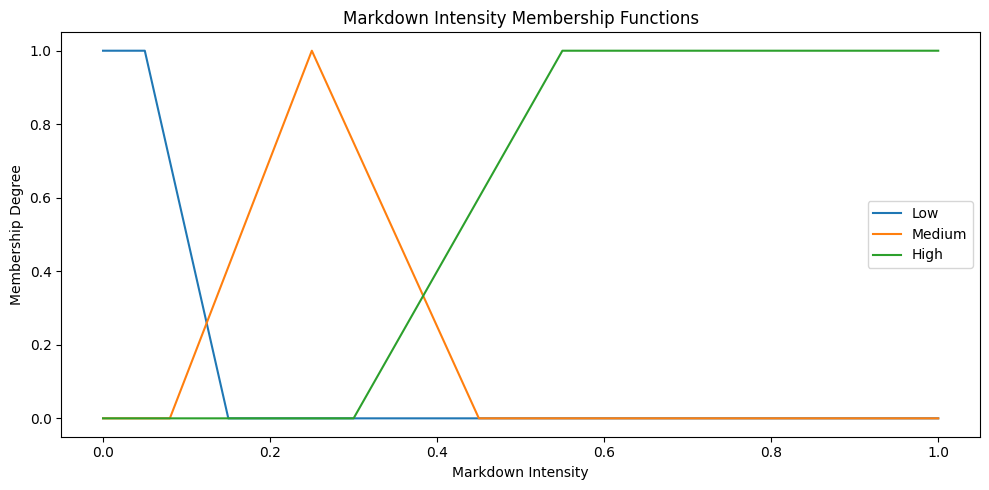

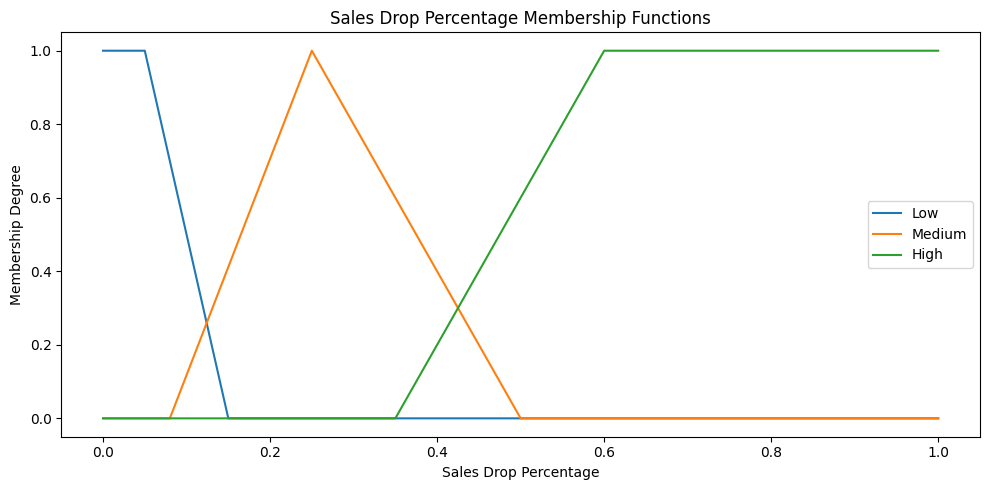

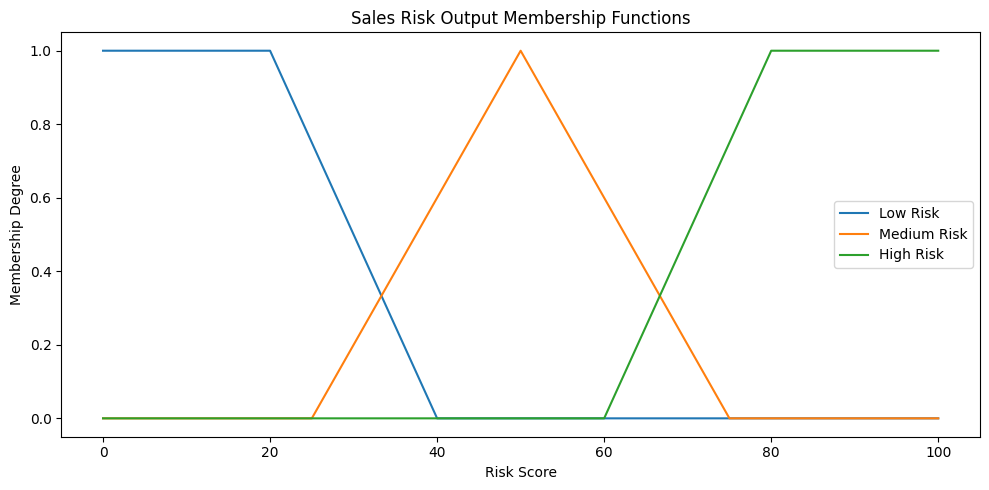

In [34]:
performance_range = np.linspace(0, 2.5, 501)
markdown_range = np.linspace(0, 1, 501)
drop_range = np.linspace(0, 1, 501)
unemployment_range = np.linspace(0, 15, 501)
risk_range = np.linspace(0, 100, 501)

performance_low = trapezoid(performance_range, 0, 0, 0.6, 0.9)
performance_medium = triangular(performance_range, 0.7, 1.0, 1.3)
performance_high = trapezoid(performance_range, 1.1, 1.4, 2.5, 2.5)

markdown_low = trapezoid(markdown_range, 0, 0, 0.05, 0.15)
markdown_medium = triangular(markdown_range, 0.08, 0.25, 0.45)
markdown_high = trapezoid(markdown_range, 0.30, 0.55, 1, 1)

drop_low = trapezoid(drop_range, 0, 0, 0.05, 0.15)
drop_medium = triangular(drop_range, 0.08, 0.25, 0.50)
drop_high = trapezoid(drop_range, 0.35, 0.60, 1, 1)

unemployment_low = trapezoid(unemployment_range, 0, 0, 4, 6)
unemployment_medium = triangular(unemployment_range, 5, 7.5, 10)
unemployment_high = trapezoid(unemployment_range, 8.5, 10, 15, 15)

risk_low = trapezoid(risk_range, 0, 0, 20, 40)
risk_medium = triangular(risk_range, 25, 50, 75)
risk_high = trapezoid(risk_range, 60, 80, 100, 100)

plt.figure(figsize=(10, 5))
plt.plot(performance_range, performance_low, label="Low")
plt.plot(performance_range, performance_medium, label="Medium")
plt.plot(performance_range, performance_high, label="High")
plt.title("Sales Performance Membership Functions")
plt.xlabel("Sales Performance")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(markdown_range, markdown_low, label="Low")
plt.plot(markdown_range, markdown_medium, label="Medium")
plt.plot(markdown_range, markdown_high, label="High")
plt.title("Markdown Intensity Membership Functions")
plt.xlabel("Markdown Intensity")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(drop_range, drop_low, label="Low")
plt.plot(drop_range, drop_medium, label="Medium")
plt.plot(drop_range, drop_high, label="High")
plt.title("Sales Drop Percentage Membership Functions")
plt.xlabel("Sales Drop Percentage")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(risk_range, risk_low, label="Low Risk")
plt.plot(risk_range, risk_medium, label="Medium Risk")
plt.plot(risk_range, risk_high, label="High Risk")
plt.title("Sales Risk Output Membership Functions")
plt.xlabel("Risk Score")
plt.ylabel("Membership Degree")
plt.legend()
plt.tight_layout()
plt.show()

---

# 22. Fuzzy Rules

The fuzzy system uses business rules.

Minimum assignment requirement is at least five rules.

This notebook uses eight rules:

| Rule | Condition | Output |
|---|---|---|
| 1 | IF sales performance is low AND sales drop is high | High risk |
| 2 | IF sales performance is low AND markdown intensity is high | High risk |
| 3 | IF unemployment is high AND sales performance is low | High risk |
| 4 | IF holiday week is true AND sales performance is low | High risk |
| 5 | IF markdown intensity is high AND sales drop is medium | High risk |
| 6 | IF sales performance is medium AND sales drop is medium | Medium risk |
| 7 | IF sales performance is medium AND markdown intensity is medium | Medium risk |
| 8 | IF sales performance is high AND sales drop is low | Low risk |


### Fuzzy DSS Score Mapping

The fuzzy DSS converts the final defuzzified score into a clear risk level.

The final score ranges from **0 to 100**.

| Fuzzy Risk Score | Risk Level | DSS Meaning | DSS Recommendation |
|---:|---|---|---|
| 0 to less than 35 | Low | Sales risk is low | Maintain current plan and monitor normally |
| 35 to less than 65 | Medium | Sales need attention | Monitor department performance and review promotions |
| 65 to 100 | High | Sales risk is high | Take management action: review stock, pricing, and markdown strategy |

Simple explanation:

| Score Range | Meaning |
|---:|---|
| 0 - 34.99 | Low risk |
| 35 - 64.99 | Medium risk |
| 65 - 100 | High risk |

The fuzzy DSS applies this mapping to every **Store + Department** combination.

Example:

| Store | Department | Risk Score | Risk Level | Decision |
|---|---:|---:|---|---|
| Store 20 | Dept 92 | 24 | Low | Keep normal monitoring |
| Store 1 | Dept 10 | 52 | Medium | Review promotions and performance |
| Store 33 | Dept 45 | 78 | High | Take management action |

In [35]:
def sales_risk_fuzzy_system(sales_performance, markdown_intensity, sales_drop_pct, unemployment, is_holiday):
    """Evaluate fuzzy sales risk and return score, label, and recommendation."""

    sales_performance = float(np.clip(sales_performance, 0, 2.5))
    markdown_intensity = float(np.clip(markdown_intensity, 0, 1))
    sales_drop_pct = float(np.clip(sales_drop_pct, 0, 1))
    unemployment = float(np.clip(unemployment, 0, 15))
    is_holiday = int(is_holiday)

    # Fuzzification
    perf_low = scalar_membership(trapezoid([sales_performance], 0, 0, 0.6, 0.9))
    perf_medium = scalar_membership(triangular([sales_performance], 0.7, 1.0, 1.3))
    perf_high = scalar_membership(trapezoid([sales_performance], 1.1, 1.4, 2.5, 2.5))

    md_low = scalar_membership(trapezoid([markdown_intensity], 0, 0, 0.05, 0.15))
    md_medium = scalar_membership(triangular([markdown_intensity], 0.08, 0.25, 0.45))
    md_high = scalar_membership(trapezoid([markdown_intensity], 0.30, 0.55, 1, 1))

    drop_low_degree = scalar_membership(trapezoid([sales_drop_pct], 0, 0, 0.05, 0.15))
    drop_medium_degree = scalar_membership(triangular([sales_drop_pct], 0.08, 0.25, 0.50))
    drop_high_degree = scalar_membership(trapezoid([sales_drop_pct], 0.35, 0.60, 1, 1))

    unemployment_low_degree = scalar_membership(trapezoid([unemployment], 0, 0, 4, 6))
    unemployment_medium_degree = scalar_membership(triangular([unemployment], 5, 7.5, 10))
    unemployment_high_degree = scalar_membership(trapezoid([unemployment], 8.5, 10, 15, 15))

    holiday_yes = float(is_holiday == 1)
    holiday_no = float(is_holiday == 0)

    # Rule activation using AND as min and OR as max
    rule_1_high = min(perf_low, drop_high_degree)
    rule_2_high = min(perf_low, md_high)
    rule_3_high = min(unemployment_high_degree, perf_low)
    rule_4_high = min(holiday_yes, perf_low)
    rule_5_high = min(md_high, drop_medium_degree)

    rule_6_medium = min(perf_medium, drop_medium_degree)
    rule_7_medium = min(perf_medium, md_medium)
    rule_8_low = min(perf_high, drop_low_degree)
    rule_9_low = min(perf_high, unemployment_low_degree)
    rule_10_low = min(perf_medium, md_low, holiday_no)

    low_activation = max(rule_8_low, rule_9_low, rule_10_low)
    medium_activation = max(rule_6_medium, rule_7_medium, min(unemployment_medium_degree, perf_medium))
    high_activation = max(rule_1_high, rule_2_high, rule_3_high, rule_4_high, rule_5_high, min(perf_low, unemployment_medium_degree))

    # Aggregation
    aggregated_risk = np.maximum.reduce([
        np.minimum(low_activation, risk_low),
        np.minimum(medium_activation, risk_medium),
        np.minimum(high_activation, risk_high)
    ])

    # Defuzzification
    score = centroid_defuzzification(risk_range, aggregated_risk)

    if score < 35:
        label = "Low"
        recommendation = "Maintain current plan and monitor normally."
    elif score < 65:
        label = "Medium"
        recommendation = "Monitor department performance and review promotions."
    else:
        label = "High"
        recommendation = "Take management action: review stock, pricing, and markdown strategy."

    rule_strengths = {
        "Low_Risk_Activation": low_activation,
        "Medium_Risk_Activation": medium_activation,
        "High_Risk_Activation": high_activation
    }

    return score, label, recommendation, rule_strengths

---

# 23. Fuzzification on a Real Walmart Record

This cell selects one real row from the Walmart data and applies the fuzzy DSS.

This satisfies the requirement to perform fuzzification on real Walmart values.

In [36]:
real_example = data.sample(1, random_state=7).iloc[0]

example_score, example_label, example_recommendation, example_rules = sales_risk_fuzzy_system(
    sales_performance=real_example["Sales_Performance"],
    markdown_intensity=real_example["Markdown_Intensity"],
    sales_drop_pct=real_example["Sales_Drop_Pct"],
    unemployment=real_example["Unemployment"],
    is_holiday=int(real_example["IsHoliday"])
)

example_table = pd.DataFrame({
    "Input": [
        "Store", "Dept", "Date", "Weekly_Sales", "Sales_Performance",
        "Markdown_Intensity", "Sales_Drop_Pct", "Unemployment", "IsHoliday",
        "Fuzzy_Risk_Score", "Risk_Label", "Recommendation"
    ],
    "Value": [
        real_example["Store"], real_example["Dept"], real_example["Date"].date(),
        round(real_example["Weekly_Sales"], 2), round(real_example["Sales_Performance"], 3),
        round(real_example["Markdown_Intensity"], 3), round(real_example["Sales_Drop_Pct"], 3),
        round(real_example["Unemployment"], 3), real_example["IsHoliday"],
        round(example_score, 2), example_label, example_recommendation
    ]
})

display(example_table)
print("Rule activation strengths")
display(pd.DataFrame([example_rules]))

,Input,Value
0,Store,37
1,Dept,7
2,Date,2012-05-04
3,Weekly_Sales,"1,007.730"
4,Sales_Performance,1.222
5,Markdown_Intensity,0.488
6,Sales_Drop_Pct,0.000
7,Unemployment,6.989
8,IsHoliday,False
9,Fuzzy_Risk_Score,31.930


Rule activation strengths


,Low_Risk_Activation,Medium_Risk_Activation,High_Risk_Activation
0,0.405,0.262,0.000


---

# 24. Apply Fuzzy Logic to Store-Department Level

Applying fuzzy logic to every individual weekly row is possible, but store-department level is more useful for management.

We aggregate the data by store and department first.

Business meaning:

Each row becomes one decision unit:

- Store 1, Department 1
- Store 1, Department 2
- Store 2, Department 1

The DSS then ranks which store-department combinations need attention.

In [37]:
fuzzy_data = data.groupby(["Store", "Dept", "Type", "Size"], as_index=False).agg(
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Total_Sales=("Weekly_Sales", "sum"),
    Sales_Performance=("Sales_Performance", "mean"),
    Total_MarkDown=("Total_MarkDown", "mean"),
    Markdown_Intensity=("Markdown_Intensity", "mean"),
    Sales_Drop_Pct=("Sales_Drop_Pct", "mean"),
    Sales_Uplift=("Sales_Uplift", "mean"),
    Unemployment=("Unemployment", "mean"),
    CPI=("CPI", "mean"),
    IsHoliday=("IsHoliday", "max")
)

fuzzy_outputs = fuzzy_data.apply(
    lambda row: sales_risk_fuzzy_system(
        row["Sales_Performance"],
        row["Markdown_Intensity"],
        row["Sales_Drop_Pct"],
        row["Unemployment"],
        int(row["IsHoliday"])
    ),
    axis=1
)

fuzzy_data["Fuzzy_Risk_Score"] = [x[0] for x in fuzzy_outputs]
fuzzy_data["Risk_Label"] = [x[1] for x in fuzzy_outputs]
fuzzy_data["DSS_Recommendation"] = [x[2] for x in fuzzy_outputs]

fuzzy_data = fuzzy_data.sort_values("Fuzzy_Risk_Score", ascending=False).reset_index(drop=True)

display(fuzzy_data.head(15))

,Store,Dept,Type,Size,Avg_Weekly_Sales,Total_Sales,Sales_Performance,Total_MarkDown,Markdown_Intensity,Sales_Drop_Pct,Sales_Uplift,Unemployment,CPI,IsHoliday,Fuzzy_Risk_Score,Risk_Label,DSS_Recommendation
0,9,78,B,125833,0.000,0.000,0.000,"5,513.660",0.997,0.000,12.880,5.667,223.759,False,84.496,High,"Take management action: review stock, pricing,..."
1,21,48,B,140167,0.000,0.000,0.000,0.000,0.000,0.500,-14.970,8.163,211.438,False,83.449,High,"Take management action: review stock, pricing,..."
2,16,78,B,57197,0.000,0.000,0.000,0.000,0.000,0.000,12.880,6.285,194.952,False,82.494,High,"Take management action: review stock, pricing,..."
3,12,49,B,112238,26.183,"1,492.440",1.000,"19,252.148",0.682,0.250,-0.191,12.495,129.838,True,68.907,High,"Take management action: review stock, pricing,..."
4,25,77,B,128107,477.000,954.000,1.000,"41,838.960",0.988,0.250,-159.000,7.082,211.526,True,68.903,High,"Take management action: review stock, pricing,..."
5,16,77,B,57197,238.500,477.000,1.000,"22,606.070",0.987,0.249,-79.500,6.232,195.796,True,68.885,High,"Take management action: review stock, pricing,..."
6,5,98,B,34875,29.976,689.450,1.000,"6,481.265",0.688,0.253,0.859,6.059,219.799,True,68.833,High,"Take management action: review stock, pricing,..."
7,45,77,B,118221,190.745,"1,525.960",1.000,"31,721.989",0.990,0.253,2.000,8.454,189.965,True,68.818,High,"Take management action: review stock, pricing,..."
8,12,77,B,112238,217.880,"1,307.280",1.000,"57,023.015",0.996,0.247,-52.020,12.538,130.143,True,68.797,High,"Take management action: review stock, pricing,..."
9,33,31,A,39690,40.070,"1,322.300",1.000,"1,199.042",0.736,0.245,0.030,7.609,130.439,True,68.674,High,"Take management action: review stock, pricing,..."


## Visualization 14: Fuzzy risk score distribution

DSS interpretation:

- This chart shows the overall risk distribution.
- A concentration in high risk means management needs urgent review.
- A concentration in medium risk means monitoring and targeted action are needed.

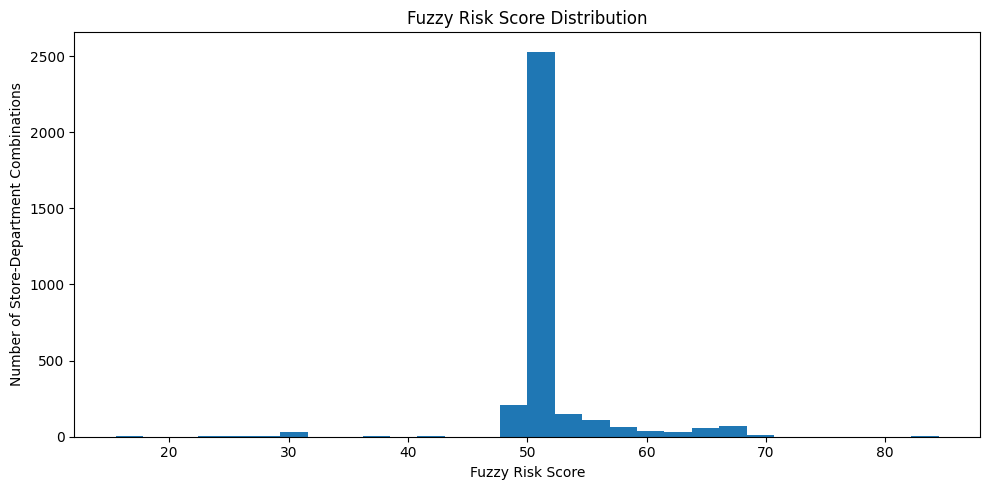

,Risk_Label,Count
0,Medium,3165
1,High,116
2,Low,50


DSS interpretation
- Risk score summarizes sales performance, markdown pressure, sales drop, unemployment, and holiday status.
- High-risk rows should be reviewed first.
- Medium-risk rows should be monitored with weekly dashboards.


In [38]:
plt.figure(figsize=(10, 5))
plt.hist(fuzzy_data["Fuzzy_Risk_Score"], bins=30)
plt.title("Fuzzy Risk Score Distribution")
plt.xlabel("Fuzzy Risk Score")
plt.ylabel("Number of Store-Department Combinations")
plt.tight_layout()
plt.show()

risk_counts = fuzzy_data["Risk_Label"].value_counts().reset_index()
risk_counts.columns = ["Risk_Label", "Count"]
display(risk_counts)

print_dss("DSS interpretation", [
    "Risk score summarizes sales performance, markdown pressure, sales drop, unemployment, and holiday status.",
    "High-risk rows should be reviewed first.",
    "Medium-risk rows should be monitored with weekly dashboards."
])

## Visualization 15: Count of fuzzy risk labels

DSS interpretation:

- This chart converts fuzzy scores into simple management categories.
- The categories support clear operational prioritization.

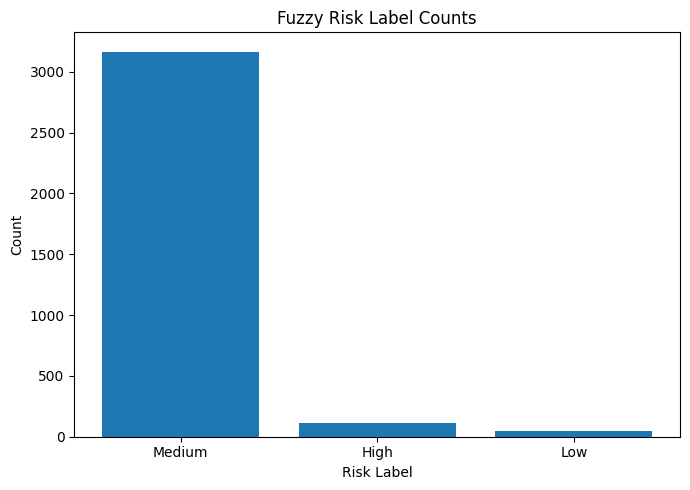

DSS interpretation
- Low risk means the current strategy is acceptable.
- Medium risk means the department needs monitoring.
- High risk means management should take action.


In [39]:
plt.figure(figsize=(7, 5))
plt.bar(risk_counts["Risk_Label"], risk_counts["Count"])
plt.title("Fuzzy Risk Label Counts")
plt.xlabel("Risk Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print_dss("DSS interpretation", [
    "Low risk means the current strategy is acceptable.",
    "Medium risk means the department needs monitoring.",
    "High risk means management should take action."
])

### DSS Interpretation: Fuzzy Risk Score Distribution

The fuzzy DSS shows that most Store-Department combinations fall in the **Medium Risk** range.

Key observations:

- Medium Risk is the dominant class with **3,165 combinations**.
- High Risk appears in **116 combinations**.
- Low Risk appears in only **50 combinations**.
- Most fuzzy scores are concentrated around **50**, which indicates moderate sales risk.

Business meaning:

Most departments inside stores are not failing, but they need monitoring.

The small High Risk group is the most important segment because it may contain weak sales performance, strong sales drops, or ineffective markdown activity.

DSS recommendation:

Management should first focus on the **116 High Risk Store-Department combinations**.

For Medium Risk combinations, the DSS recommends regular monitoring and promotion review.

Low Risk combinations can keep the current plan with normal follow-up.

---

## Exact Fuzzy Risk Location

This section shows exactly where each fuzzy risk level appears.

Each point represents one Store-Department combination.

The DSS uses this view to identify:

- High Risk combinations that need management action
- Medium Risk combinations that need monitoring
- Low Risk combinations that can continue with normal follow-up

EXACT RISK LOCATION TABLE


,Store,Dept,Fuzzy_Risk_Score,Risk_Label,DSS_Recommendation
0,9,78,84.496,High,"Take management action: review stock, pricing,..."
1,21,48,83.449,High,"Take management action: review stock, pricing,..."
2,16,78,82.494,High,"Take management action: review stock, pricing,..."
3,12,49,68.907,High,"Take management action: review stock, pricing,..."
4,25,77,68.903,High,"Take management action: review stock, pricing,..."
5,16,77,68.885,High,"Take management action: review stock, pricing,..."
6,5,98,68.833,High,"Take management action: review stock, pricing,..."
7,45,77,68.818,High,"Take management action: review stock, pricing,..."
8,12,77,68.797,High,"Take management action: review stock, pricing,..."
9,33,31,68.674,High,"Take management action: review stock, pricing,..."


HIGH RISK COMBINATIONS
Count: 116


,Store,Dept,Fuzzy_Risk_Score,Risk_Label,DSS_Recommendation
0,9,78,84.496,High,"Take management action: review stock, pricing,..."
1,21,48,83.449,High,"Take management action: review stock, pricing,..."
2,16,78,82.494,High,"Take management action: review stock, pricing,..."
3,12,49,68.907,High,"Take management action: review stock, pricing,..."
4,25,77,68.903,High,"Take management action: review stock, pricing,..."
5,16,77,68.885,High,"Take management action: review stock, pricing,..."
6,5,98,68.833,High,"Take management action: review stock, pricing,..."
7,45,77,68.818,High,"Take management action: review stock, pricing,..."
8,12,77,68.797,High,"Take management action: review stock, pricing,..."
9,33,31,68.674,High,"Take management action: review stock, pricing,..."


MEDIUM RISK COMBINATIONS
Count: 3165


,Store,Dept,Fuzzy_Risk_Score,Risk_Label,DSS_Recommendation
116,34,77,64.997,Medium,Monitor department performance and review prom...
117,38,49,64.989,Medium,Monitor department performance and review prom...
118,16,49,64.958,Medium,Monitor department performance and review prom...
119,11,77,64.897,Medium,Monitor department performance and review prom...
120,37,49,64.848,Medium,Monitor department performance and review prom...
121,9,94,64.801,Medium,Monitor department performance and review prom...
122,13,47,64.784,Medium,Monitor department performance and review prom...
123,16,47,64.733,Medium,Monitor department performance and review prom...
124,9,77,64.695,Medium,Monitor department performance and review prom...
125,23,60,64.653,Medium,Monitor department performance and review prom...


LOW RISK COMBINATIONS
Count: 50


,Store,Dept,Fuzzy_Risk_Score,Risk_Label,DSS_Recommendation
3281,11,50,31.067,Low,Maintain current plan and monitor normally.
3282,3,45,31.054,Low,Maintain current plan and monitor normally.
3283,3,78,31.043,Low,Maintain current plan and monitor normally.
3284,28,51,30.988,Low,Maintain current plan and monitor normally.
3285,45,51,30.978,Low,Maintain current plan and monitor normally.
3286,15,45,30.963,Low,Maintain current plan and monitor normally.
3287,15,43,30.958,Low,Maintain current plan and monitor normally.
3288,30,27,30.950,Low,Maintain current plan and monitor normally.
3289,20,51,30.931,Low,Maintain current plan and monitor normally.
3290,9,51,30.929,Low,Maintain current plan and monitor normally.


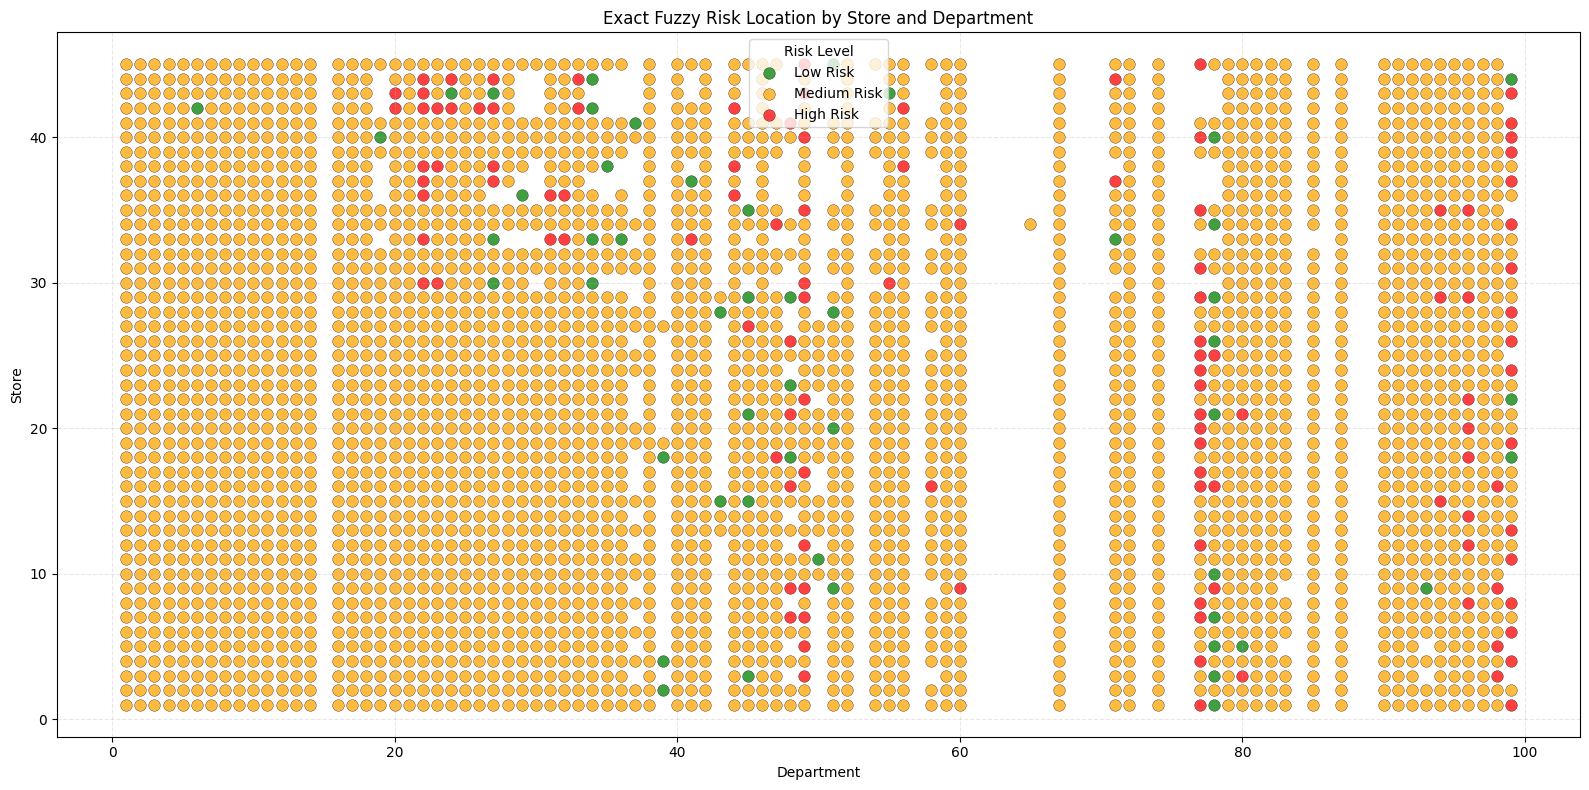

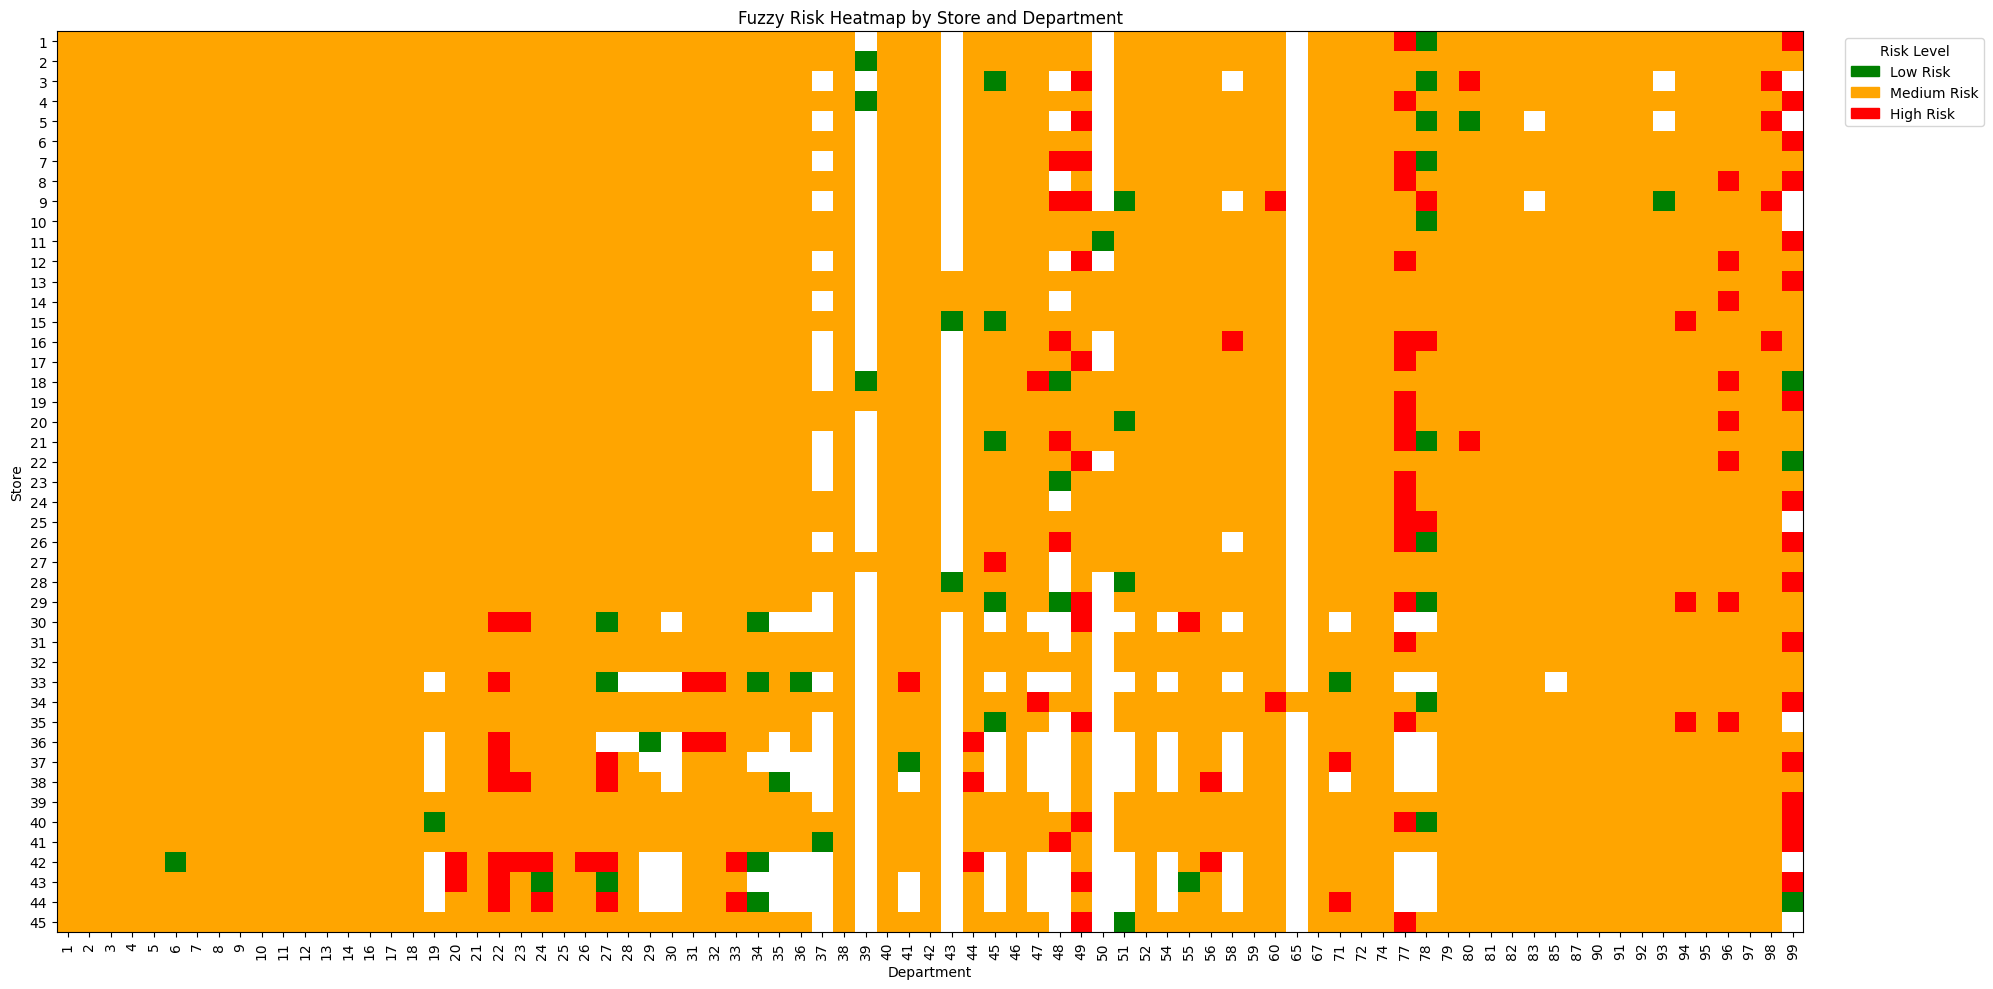

In [70]:
# ============================================================
# Exact Fuzzy Risk Location Analysis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

# ------------------------------------------------------------
# 1. Validate required columns
# ------------------------------------------------------------

required_cols = ["Store", "Dept", "Fuzzy_Risk_Score", "Risk_Label"]

missing_cols = [col for col in required_cols if col not in fuzzy_data.columns]

if missing_cols:
    raise ValueError(f"Missing columns in fuzzy_data: {missing_cols}")

# ------------------------------------------------------------
# 2. Prepare exact risk location table
# ------------------------------------------------------------

risk_location = fuzzy_data.copy()

risk_location["Risk_Code"] = risk_location["Risk_Label"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

risk_location = risk_location.sort_values(
    ["Risk_Code", "Fuzzy_Risk_Score", "Store", "Dept"],
    ascending=[False, False, True, True]
)

display_cols = [
    "Store",
    "Dept",
    "Fuzzy_Risk_Score",
    "Risk_Label",
    "DSS_Recommendation"
]

available_display_cols = [col for col in display_cols if col in risk_location.columns]

print("=" * 100)
print("EXACT RISK LOCATION TABLE")
print("=" * 100)

display(risk_location[available_display_cols].head(50))

# ------------------------------------------------------------
# 3. Print separate tables for High, Medium, and Low
# ------------------------------------------------------------

for label in ["High", "Medium", "Low"]:
    subset = risk_location[risk_location["Risk_Label"] == label].copy()
    
    print("=" * 100)
    print(f"{label.upper()} RISK COMBINATIONS")
    print("Count:", subset.shape[0])
    print("=" * 100)
    
    display(subset[available_display_cols].head(30))

# ============================================================
# Scatter Plot: Exact Risk Location by Store and Department
# ============================================================

risk_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

plt.figure(figsize=(16, 8))

for label in ["Low", "Medium", "High"]:
    subset = risk_location[risk_location["Risk_Label"] == label]
    
    plt.scatter(
        subset["Dept"],
        subset["Store"],
        label=f"{label} Risk",
        color=risk_colors[label],
        alpha=0.75,
        s=70,
        edgecolors="black",
        linewidths=0.3
    )

plt.title("Exact Fuzzy Risk Location by Store and Department")
plt.xlabel("Department")
plt.ylabel("Store")
plt.legend(title="Risk Level")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()



# ============================================================
# Heatmap: Risk Level by Store and Department
# ============================================================

risk_pivot = risk_location.pivot_table(
    index="Store",
    columns="Dept",
    values="Risk_Code",
    aggfunc="max"
)

risk_cmap = ListedColormap(["green", "orange", "red"])
risk_norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5], risk_cmap.N)

plt.figure(figsize=(20, 10))

heatmap = plt.imshow(
    risk_pivot,
    aspect="auto",
    cmap=risk_cmap,
    norm=risk_norm
)

plt.title("Fuzzy Risk Heatmap by Store and Department")
plt.xlabel("Department")
plt.ylabel("Store")

plt.xticks(
    ticks=range(len(risk_pivot.columns)),
    labels=risk_pivot.columns,
    rotation=90
)

plt.yticks(
    ticks=range(len(risk_pivot.index)),
    labels=risk_pivot.index
)

legend_items = [
    mpatches.Patch(color="green", label="Low Risk"),
    mpatches.Patch(color="orange", label="Medium Risk"),
    mpatches.Patch(color="red", label="High Risk")
]

plt.legend(
    handles=legend_items,
    title="Risk Level",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()



### DSS Interpretation: Exact Risk Location

The scatter plot and heatmap show the exact Store-Department combinations for each fuzzy risk level.

Key observations:

- Red points show High Risk combinations.
- Orange points show Medium Risk combinations.
- Green points show Low Risk combinations.
- The DSS identifies the exact department inside each store, not only the whole store.

Business meaning:

Risk is not equal across all departments inside the same store.

A store may have safe departments and risky departments at the same time.

DSS recommendation:

Management should start with the High Risk combinations shown in red.

Medium Risk combinations should be monitored weekly.

Low Risk combinations can continue with the current plan.

---

## Top high-risk store-department combinations

This table is the direct DSS output.

Managers can use it as an action list.

,Store,Dept,Type,Size,Avg_Weekly_Sales,Sales_Performance,Markdown_Intensity,Sales_Drop_Pct,Unemployment,Fuzzy_Risk_Score,DSS_Recommendation
0,9,78,B,125833,0.000,0.000,0.997,0.000,5.667,84.496,"Take management action: review stock, pricing,..."
1,21,48,B,140167,0.000,0.000,0.000,0.500,8.163,83.449,"Take management action: review stock, pricing,..."
2,16,78,B,57197,0.000,0.000,0.000,0.000,6.285,82.494,"Take management action: review stock, pricing,..."
3,12,49,B,112238,26.183,1.000,0.682,0.250,12.495,68.907,"Take management action: review stock, pricing,..."
4,25,77,B,128107,477.000,1.000,0.988,0.250,7.082,68.903,"Take management action: review stock, pricing,..."
5,16,77,B,57197,238.500,1.000,0.987,0.249,6.232,68.885,"Take management action: review stock, pricing,..."
6,5,98,B,34875,29.976,1.000,0.688,0.253,6.059,68.833,"Take management action: review stock, pricing,..."
7,45,77,B,118221,190.745,1.000,0.990,0.253,8.454,68.818,"Take management action: review stock, pricing,..."
8,12,77,B,112238,217.880,1.000,0.996,0.247,12.538,68.797,"Take management action: review stock, pricing,..."
9,33,31,A,39690,40.070,1.000,0.736,0.245,7.609,68.674,"Take management action: review stock, pricing,..."


STORES WITH THE MOST HIGH RISK DEPARTMENTS


,Store,High_Risk_Departments
38,42,9
34,38,5
40,44,5
7,9,5
13,16,5
33,37,4
27,30,4
29,33,4
31,35,4
32,36,4


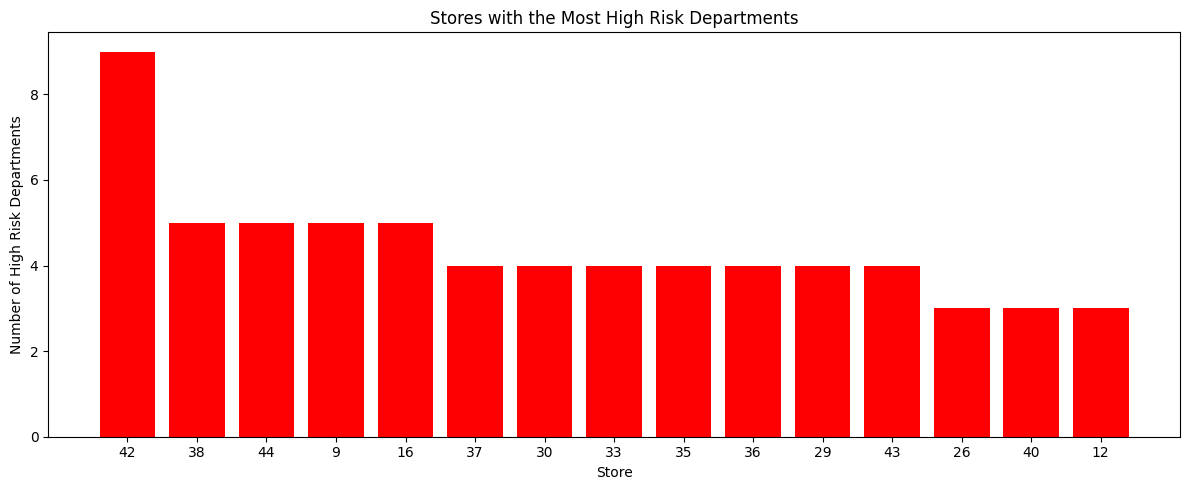

DEPARTMENTS WITH THE MOST HIGH RISK STORES


,Dept,High_Risk_Stores
20,77,19
26,99,17
14,49,13
1,22,8
24,96,8
13,48,6
25,98,4
5,27,4
2,23,3
10,44,3


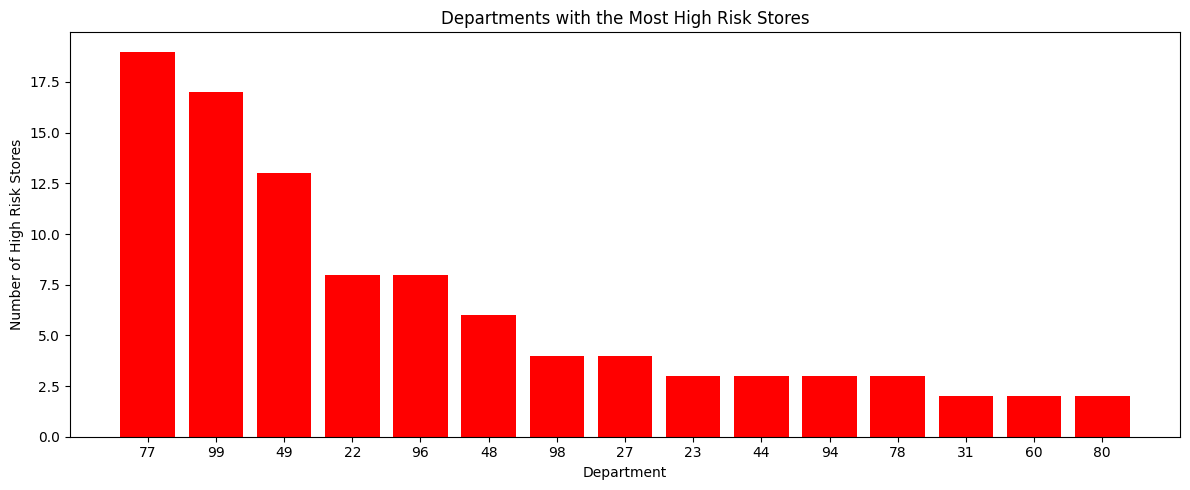

DSS action list
- Start with the highest risk score.
- Check whether markdowns are high but sales response is weak.
- Review stock availability and price competitiveness for these departments.
- Compare high-risk departments with similar departments in better stores.


In [72]:
high_risk_table = fuzzy_data[fuzzy_data["Risk_Label"] == "High"].copy()

display(high_risk_table[[
    "Store", "Dept", "Type", "Size", "Avg_Weekly_Sales", "Sales_Performance",
    "Markdown_Intensity", "Sales_Drop_Pct", "Unemployment", "Fuzzy_Risk_Score", "DSS_Recommendation"
]].head(20))

# ============================================================
# Where High Risk Appears Most
# ============================================================

high_risk_only = risk_location[risk_location["Risk_Label"] == "High"].copy()

high_risk_by_store = (
    high_risk_only
    .groupby("Store", as_index=False)
    .agg(High_Risk_Departments=("Dept", "count"))
    .sort_values("High_Risk_Departments", ascending=False)
)

high_risk_by_dept = (
    high_risk_only
    .groupby("Dept", as_index=False)
    .agg(High_Risk_Stores=("Store", "count"))
    .sort_values("High_Risk_Stores", ascending=False)
)

print("=" * 100)
print("STORES WITH THE MOST HIGH RISK DEPARTMENTS")
print("=" * 100)
display(high_risk_by_store.head(15))

plt.figure(figsize=(12, 5))
plt.bar(
    high_risk_by_store["Store"].astype(str).head(15),
    high_risk_by_store["High_Risk_Departments"].head(15),
    color="red"
)
plt.title("Stores with the Most High Risk Departments")
plt.xlabel("Store")
plt.ylabel("Number of High Risk Departments")
plt.tight_layout()
plt.show()


print("=" * 100)
print("DEPARTMENTS WITH THE MOST HIGH RISK STORES")
print("=" * 100)
display(high_risk_by_dept.head(15))

plt.figure(figsize=(12, 5))
plt.bar(
    high_risk_by_dept["Dept"].astype(str).head(15),
    high_risk_by_dept["High_Risk_Stores"].head(15),
    color="red"
)
plt.title("Departments with the Most High Risk Stores")
plt.xlabel("Department")
plt.ylabel("Number of High Risk Stores")
plt.tight_layout()
plt.show()

print_dss("DSS action list", [
    "Start with the highest risk score.",
    "Check whether markdowns are high but sales response is weak.",
    "Review stock availability and price competitiveness for these departments.",
    "Compare high-risk departments with similar departments in better stores."
])




---

# 25. Promotion Effectiveness View

The fuzzy system focuses on sales risk.

We also create a simple promotion effectiveness view using OLAP measures.

Business logic:

- High markdown with low uplift means weak promotion response.
- Low markdown with high uplift means strong organic demand.
- High markdown with high uplift means promotion may be effective.

In [41]:
promo_data = data.groupby(["Store", "Dept"], as_index=False).agg(
    Average_MarkDown=("Total_MarkDown", "mean"),
    Average_Uplift=("Sales_Uplift", "mean"),
    Average_Sales=("Weekly_Sales", "mean")
)

markdown_median = promo_data["Average_MarkDown"].median()
uplift_median = promo_data["Average_Uplift"].median()

conditions = [
    (promo_data["Average_MarkDown"] >= markdown_median) & (promo_data["Average_Uplift"] < uplift_median),
    (promo_data["Average_MarkDown"] >= markdown_median) & (promo_data["Average_Uplift"] >= uplift_median),
    (promo_data["Average_MarkDown"] < markdown_median) & (promo_data["Average_Uplift"] >= uplift_median)
]
choices = ["Weak promotion response", "Possible effective promotion", "Strong demand without heavy markdown"]

promo_data["Promotion_Effectiveness"] = np.select(conditions, choices, default="Normal")

display(promo_data.sort_values("Average_MarkDown", ascending=False).head(15))

,Store,Dept,Average_MarkDown,Average_Uplift,Average_Sales,Promotion_Effectiveness
738,10,77,"143,223.310",0.000,"1,590.000",Possible effective promotion
969,13,77,"114,565.270",0.000,"1,272.000",Possible effective promotion
949,13,43,"70,523.390",0.000,1.070,Possible effective promotion
890,12,77,"57,023.015",-52.020,217.880,Weak promotion response
1046,14,77,"54,929.308",-30.000,248.250,Weak promotion response
1576,21,50,"54,502.590",0.000,10.000,Possible effective promotion
136,2,77,"52,462.025",-613.500,817.500,Weak promotion response
2127,28,77,"50,783.943",92.000,463.000,Possible effective promotion
435,6,77,"46,938.065",-646.815,625.185,Weak promotion response
2344,31,77,"43,753.662",-130.843,192.333,Weak promotion response


## Visualization 16: Promotion effectiveness categories

DSS interpretation:

- Weak promotion response needs campaign review.
- Possible effective promotion can be repeated with monitoring.
- Strong demand without heavy markdown may not need discounting.

,Promotion_Effectiveness,Count
0,Weak promotion response,956
1,Strong demand without heavy markdown,942
2,Possible effective promotion,724
3,Normal,709


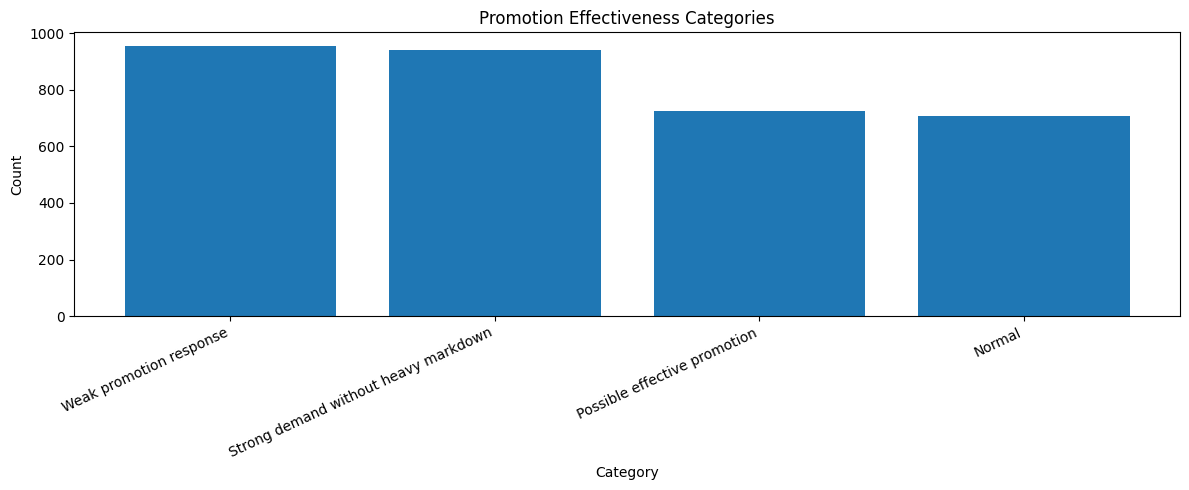

DSS interpretation
- Promotion effectiveness should be reviewed at store-department level.
- High markdown without uplift is a warning signal.
- Departments with strong demand may not need heavy discounts.


In [42]:
promo_counts = promo_data["Promotion_Effectiveness"].value_counts().reset_index()
promo_counts.columns = ["Promotion_Effectiveness", "Count"]

display(promo_counts)

plt.figure(figsize=(12, 5))
plt.bar(promo_counts["Promotion_Effectiveness"], promo_counts["Count"])
plt.title("Promotion Effectiveness Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print_dss("DSS interpretation", [
    "Promotion effectiveness should be reviewed at store-department level.",
    "High markdown without uplift is a warning signal.",
    "Departments with strong demand may not need heavy discounts."
])

---

# 26. Machine Learning Model

We train **Random Forest** classifier.

The model learns to predict the fuzzy risk label from store-department features.

This is useful for deployment because the user can enter a business case and get a predicted risk class.

## Target

Risk_Label from the fuzzy DSS:

- Low
- Medium
- High

## Features

- Store
- Dept
- Type
- Size
- Average weekly sales
- Sales performance
- Total markdown
- Markdown intensity
- Sales drop percentage
- Unemployment
- CPI
- IsHoliday

In [43]:
model_data = fuzzy_data.copy()

feature_cols = [
    "Store", "Dept", "Type", "Size", "Avg_Weekly_Sales", "Sales_Performance",
    "Total_MarkDown", "Markdown_Intensity", "Sales_Drop_Pct",
    "Unemployment", "CPI", "IsHoliday"
]

target_col = "Risk_Label"

X = model_data[feature_cols]
y = model_data[target_col]

print("Model data shape:", X.shape)
print("Target distribution")
display(y.value_counts().reset_index().rename(columns={"index": "Risk_Label", target_col: "Count"}))

Model data shape: (3331, 12)
Target distribution


,Count,count
0,Medium,3165
1,High,116
2,Low,50


## Train-test split and Random Forest model

The model uses a preprocessing pipeline.

- Type is encoded as a categorical feature.
- Numeric features are used directly.
- The Random Forest is kept small to run quickly.

In [44]:
categorical_features = ["Type"]
numeric_features = [col for col in feature_cols if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

ml_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

stratify_target = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=stratify_target
)

ml_pipeline.fit(X_train, y_train)

y_pred = ml_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))
print("\nClassification report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9844

Classification report
              precision    recall  f1-score   support

        High       0.74      0.86      0.79        29
         Low       0.87      1.00      0.93        13
      Medium       1.00      0.99      0.99       791

    accuracy                           0.98       833
   macro avg       0.87      0.95      0.91       833
weighted avg       0.99      0.98      0.99       833



## Visualization 17: Confusion matrix

DSS interpretation:

- The confusion matrix shows how well the model predicts each risk class.
- Good performance means the model can support a simple deployment interface.
- Errors between medium and high risk should be treated carefully in business use.

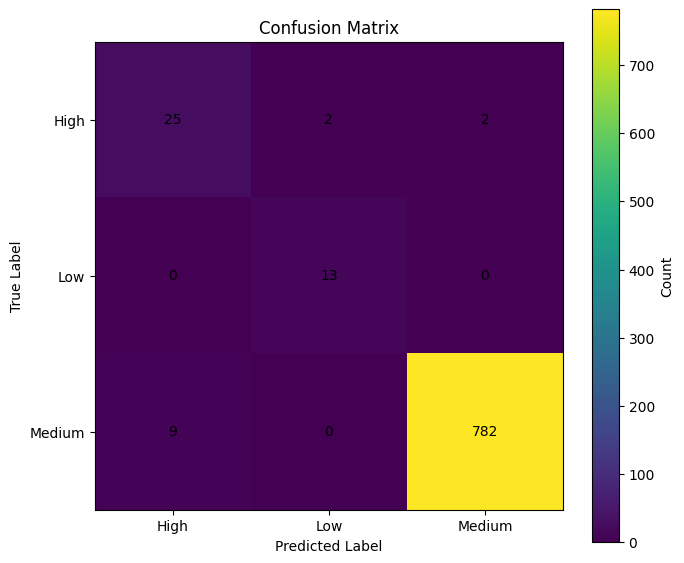

In [73]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar(label="Count")

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()



## Visualization 18: Feature importance



,Feature,Importance
9,Markdown_Intensity,0.348
8,Total_MarkDown,0.212
13,IsHoliday,0.134
10,Sales_Drop_Pct,0.113
6,Avg_Weekly_Sales,0.109
12,CPI,0.028
4,Dept,0.020
5,Size,0.013
11,Unemployment,0.010
3,Store,0.006


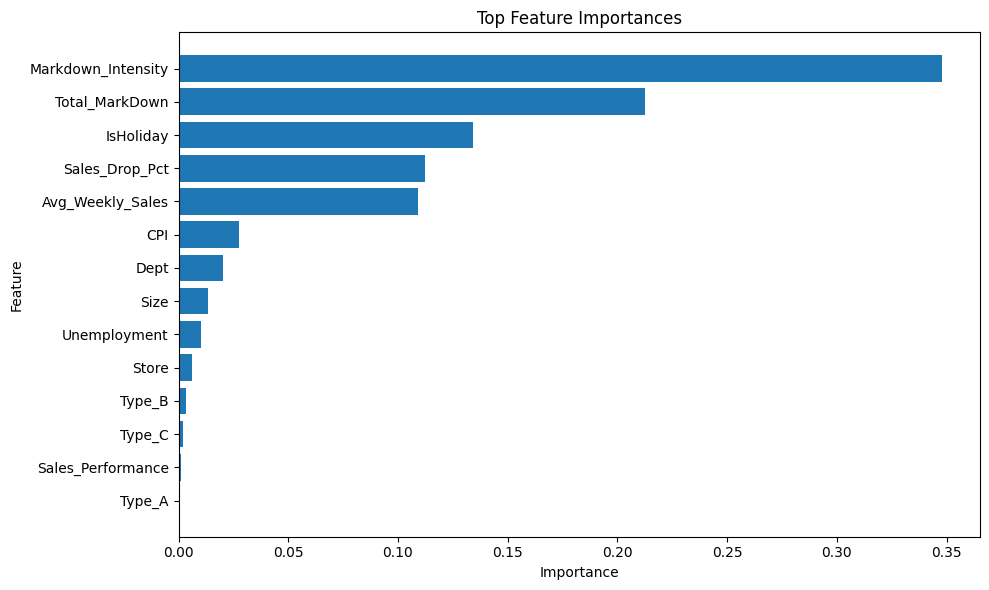

 interpretation
- The most important features explain what drives the predicted risk class.
- If sales performance and sales drop are important, the model agrees with the DSS logic.
- If economic features are important, local market pressure should be monitored.


In [74]:
trained_preprocessor = ml_pipeline.named_steps["preprocessor"]
trained_model = ml_pipeline.named_steps["model"]

try:
    cat_names = list(trained_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
except Exception:
    cat_names = categorical_features

all_feature_names = cat_names + numeric_features
importances = trained_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"].head(15)[::-1], feature_importance["Importance"].head(15)[::-1])
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print_dss(" interpretation", [
    "The most important features explain what drives the predicted risk class.",
    "If sales performance and sales drop are important, the model agrees with the DSS logic.",
    "If economic features are important, local market pressure should be monitored."
])

---

# 27. Gradio Deployment System

This section creates a small interactive DSS interface.

The user enters store, department, markdown, sales performance, sales drop, unemployment, and other business features.

The system returns:

- Random Forest predicted risk label
- Fuzzy risk score
- Fuzzy risk label
- DSS recommendation

This acts like a simple deployment prototype.

In [47]:
def dss_predict(
    store,
    dept,
    store_type,
    size,
    avg_weekly_sales,
    sales_performance,
    total_markdown,
    markdown_intensity,
    sales_drop_pct,
    unemployment,
    cpi,
    is_holiday
):
    input_df = pd.DataFrame([{
        "Store": int(store),
        "Dept": int(dept),
        "Type": str(store_type),
        "Size": float(size),
        "Avg_Weekly_Sales": float(avg_weekly_sales),
        "Sales_Performance": float(sales_performance),
        "Total_MarkDown": float(total_markdown),
        "Markdown_Intensity": float(markdown_intensity),
        "Sales_Drop_Pct": float(sales_drop_pct),
        "Unemployment": float(unemployment),
        "CPI": float(cpi),
        "IsHoliday": bool(is_holiday)
    }])

    model_prediction = ml_pipeline.predict(input_df)[0]

    fuzzy_score, fuzzy_label, recommendation, rule_strengths = sales_risk_fuzzy_system(
        sales_performance=float(sales_performance),
        markdown_intensity=float(markdown_intensity),
        sales_drop_pct=float(sales_drop_pct),
        unemployment=float(unemployment),
        is_holiday=int(is_holiday)
    )

    result = {
        "Random Forest Risk Label": model_prediction,
        "Fuzzy Risk Score": round(fuzzy_score, 2),
        "Fuzzy Risk Label": fuzzy_label,
        "DSS Recommendation": recommendation,
        "Low Risk Activation": round(rule_strengths["Low_Risk_Activation"], 3),
        "Medium Risk Activation": round(rule_strengths["Medium_Risk_Activation"], 3),
        "High Risk Activation": round(rule_strengths["High_Risk_Activation"], 3)
    }

    return result

sample_case = model_data.iloc[0]

dss_predict(
    store=sample_case["Store"],
    dept=sample_case["Dept"],
    store_type=sample_case["Type"],
    size=sample_case["Size"],
    avg_weekly_sales=sample_case["Avg_Weekly_Sales"],
    sales_performance=sample_case["Sales_Performance"],
    total_markdown=sample_case["Total_MarkDown"],
    markdown_intensity=sample_case["Markdown_Intensity"],
    sales_drop_pct=sample_case["Sales_Drop_Pct"],
    unemployment=sample_case["Unemployment"],
    cpi=sample_case["CPI"],
    is_holiday=bool(sample_case["IsHoliday"])
)

{'Random Forest Risk Label': 'High',
 'Fuzzy Risk Score': 84.5,
 'Fuzzy Risk Label': 'High',
 'DSS Recommendation': 'Take management action: review stock, pricing, and markdown strategy.',
 'Low Risk Activation': 0.0,
 'Medium Risk Activation': 0.0,
 'High Risk Activation': 1.0}

## Launch Gradio app

Run this cell to open the interactive DSS interface.

If Gradio is not installed, the cell will try to install it first.

In [48]:
try:
    import gradio as gr
except Exception:
    ensure_package("gradio", "gradio")
    import gradio as gr

store_values = sorted(model_data["Store"].unique().tolist())
dept_values = sorted(model_data["Dept"].unique().tolist())
type_values = sorted(model_data["Type"].unique().tolist())

default_case = model_data.iloc[0]

with gr.Blocks(title="Walmart Sales Risk DSS") as demo:
    gr.Markdown("# Walmart Sales Risk Decision Support System")
    gr.Markdown("Enter a store-department case to get a Random Forest prediction and fuzzy DSS recommendation.")

    with gr.Row():
        store_input = gr.Dropdown(choices=store_values, value=int(default_case["Store"]), label="Store")
        dept_input = gr.Dropdown(choices=dept_values, value=int(default_case["Dept"]), label="Department")
        type_input = gr.Dropdown(choices=type_values, value=str(default_case["Type"]), label="Store Type")

    with gr.Row():
        size_input = gr.Number(value=float(default_case["Size"]), label="Store Size")
        avg_sales_input = gr.Number(value=float(default_case["Avg_Weekly_Sales"]), label="Average Weekly Sales")
        cpi_input = gr.Number(value=float(default_case["CPI"]), label="CPI")

    with gr.Row():
        performance_input = gr.Slider(0, 2.5, value=float(default_case["Sales_Performance"]), step=0.01, label="Sales Performance")
        markdown_input = gr.Number(value=float(default_case["Total_MarkDown"]), label="Total MarkDown")
        markdown_intensity_input = gr.Slider(0, 1, value=float(default_case["Markdown_Intensity"]), step=0.01, label="Markdown Intensity")

    with gr.Row():
        drop_input = gr.Slider(0, 1, value=float(default_case["Sales_Drop_Pct"]), step=0.01, label="Sales Drop Percentage")
        unemployment_input = gr.Slider(0, 15, value=float(default_case["Unemployment"]), step=0.01, label="Unemployment")
        holiday_input = gr.Checkbox(value=bool(default_case["IsHoliday"]), label="Holiday Week")

    predict_button = gr.Button("Predict DSS Risk")
    output_json = gr.JSON(label="DSS Output")

    predict_button.click(
        fn=dss_predict,
        inputs=[
            store_input, dept_input, type_input, size_input, avg_sales_input,
            performance_input, markdown_input, markdown_intensity_input,
            drop_input, unemployment_input, cpi_input, holiday_input
        ],
        outputs=output_json
    )

# Use prevent_thread_lock=True so the notebook can continue after launching.
demo.launch(share=False, inline=True, prevent_thread_lock=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---

# 28. Final DSS Recommendations



This section summarizes the most important findings from the OLAP analysis, fuzzy DSS output, and machine learning model.

The final summary highlights the best and weakest stores, department performance, high-risk combinations, model accuracy, and key business correlations.

The recommendation table converts the analytical findings into practical decision-support actions for Walmart management.

In [76]:
# ============================================================
# Final Summary and Recommendations - Professional Display
# ============================================================

import pandas as pd
from IPython.display import display, HTML

# ------------------------------------------------------------
# 1. Final summary as clean readable values
# ------------------------------------------------------------

final_summary_df = pd.DataFrame({
    "Finding": [
        "Highest total sales store",
        "Lowest total sales store",
        "Highest total sales department",
        "Lowest total sales department",
        "Number of high risk store-department combinations",
        "Random Forest test accuracy",
        "Markdown-sales correlation",
        "Unemployment-sales correlation"
    ],
    "Value": [
        f"Store {int(store_sales.iloc[0]['Store'])}",
        f"Store {int(store_sales.iloc[-1]['Store'])}",
        f"Department {int(dept_sales.iloc[0]['Dept'])}",
        f"Department {int(dept_sales.iloc[-1]['Dept'])}",
        f"{int((fuzzy_data['Risk_Label'] == 'High').sum())} combinations",
        f"{round(float(accuracy) * 100, 2)}%",
        round(float(corr_markdown_sales), 4),
        round(float(corr_unemp_sales), 4)
    ]
})

display(
    final_summary_df.style
    .set_caption("Final DSS Summary")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "20px"),
                ("font-weight", "bold"),
                ("color", "#1f4e79"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "10px"),
                ("text-align", "left"),
                ("border-bottom", "1px solid #ddd")
            ]
        }
    ])
    .hide(axis="index")
)

# ------------------------------------------------------------
# 2. Final recommendations table
# ------------------------------------------------------------

final_recommendations = pd.DataFrame({
    "No.": [1, 2, 3, 4, 5, 6],
    "Recommendation": [
        "Prioritize high-risk store-department combinations from the fuzzy DSS table.",
        "Review departments with high markdown intensity and weak sales uplift.",
        "Plan holiday inventory using monthly and weekly sales trends.",
        "Compare stores within the same store type before judging performance.",
        "Use the Random Forest model as a quick deployment layer, but keep fuzzy rules as the explainable decision layer.",
        "Create weekly monitoring for Sales_Performance, Sales_Drop_Pct, and Markdown_Intensity."
    ],
    "Business Reason": [
        "They combine weak performance, sales drops, promotion pressure, and economic risk.",
        "High discount spending without sales response can reduce profitability.",
        "Seasonal peaks and drops are visible in the OLAP trend charts.",
        "Different store types have different sales capacity.",
        "The model predicts fast while fuzzy logic explains the decision.",
        "These features directly drive DSS risk recommendations."
    ]
})

display(
    final_recommendations.style
    .set_caption("Final DSS Recommendations")
    .set_properties(
        subset=["Recommendation", "Business Reason"],
        **{
            "text-align": "left",
            "white-space": "normal",
            "width": "420px",
            "line-height": "1.5"
        }
    )
    .set_properties(
        subset=["No."],
        **{
            "text-align": "center",
            "width": "60px"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "20px"),
                ("font-weight", "bold"),
                ("color", "#1f4e79"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding", "10px")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "12px"),
                ("border-bottom", "1px solid #ddd"),
                ("vertical-align", "top")
            ]
        }
    ])
    .hide(axis="index")
)

Finding,Value
Highest total sales store,Store 20
Lowest total sales store,Store 33
Highest total sales department,Department 92
Lowest total sales department,Department 47
Number of high risk store-department combinations,116 combinations
Random Forest test accuracy,98.44%
Markdown-sales correlation,0.065200
Unemployment-sales correlation,-0.025900


No.,Recommendation,Business Reason
1,Prioritize high-risk store-department combinations from the fuzzy DSS table.,"They combine weak performance, sales drops, promotion pressure, and economic risk."
2,Review departments with high markdown intensity and weak sales uplift.,High discount spending without sales response can reduce profitability.
3,Plan holiday inventory using monthly and weekly sales trends.,Seasonal peaks and drops are visible in the OLAP trend charts.
4,Compare stores within the same store type before judging performance.,Different store types have different sales capacity.
5,"Use the Random Forest model as a quick deployment layer, but keep fuzzy rules as the explainable decision layer.",The model predicts fast while fuzzy logic explains the decision.
6,"Create weekly monitoring for Sales_Performance, Sales_Drop_Pct, and Markdown_Intensity.",These features directly drive DSS risk recommendations.


---

# 29. Conclusion



## Final business conclusion

OLAP explains what happened in Walmart sales.

Fuzzy logic converts business uncertainty into a clear risk score.

The Random Forest model provides a simple deployment layer.

The Gradio system allows a user to test new store-department cases through an interactive interface.

---